# **Análisis Exploratorio de Siniestros Viales Fatales en Argentina (2017-2023)**

> El presente trabajo constituye el proyecto final para la materia Minería de Datos. El objetivo principal es realizar un Análisis Exploratorio de Datos (EDA) sobre la siniestralidad vial fatal en la República Argentina durante el periodo 2017-2023. El enfoque principal estuvo en el procesamiento, limpieza y transformación de los datos para detectar perfiles de riesgo y comportamientos temporales. La idea del análisis es mostrar cómo se distribuyen los accidentes fatales y usar la estadística para entender mejor la realidad vial actual, pasando de los datos crudos a conclusiones que expliquen la dinámica de estos hechos.






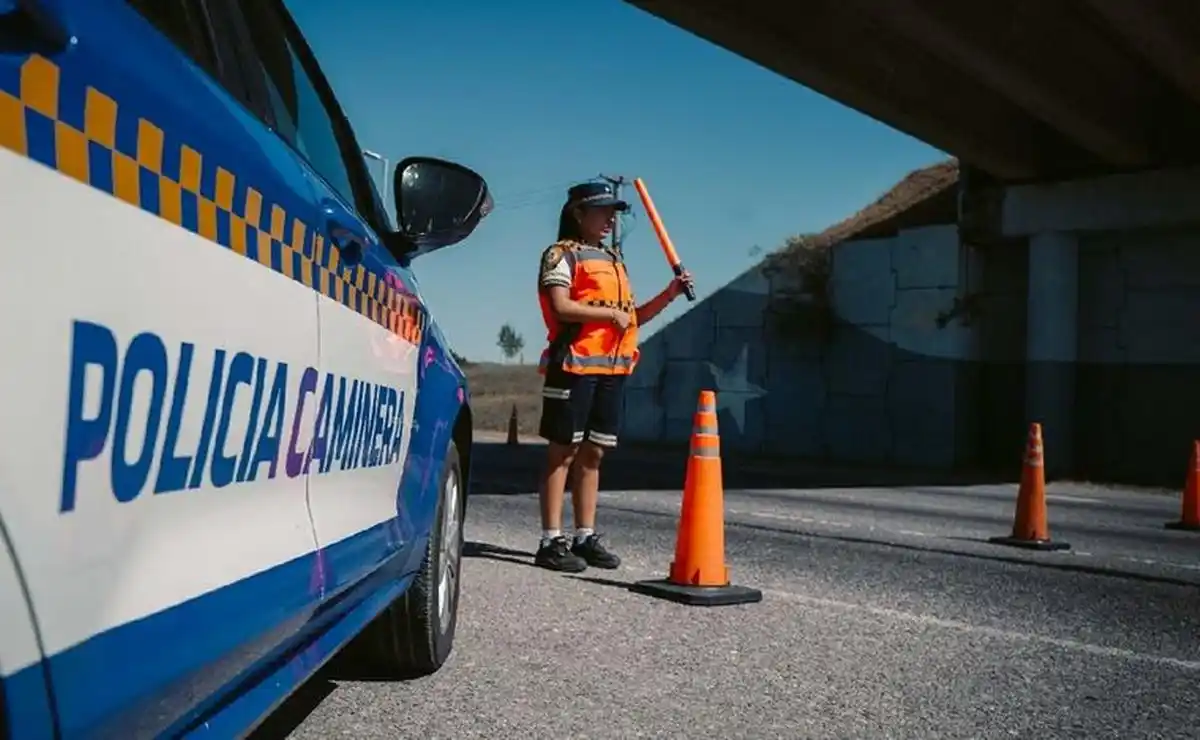

#**Objetivos del Proyecto**

*Objetivo General*

Analizar  la evolución de los siniestros viales fatales en Argentina entre 2017 y 2023, aplicando técnicas de Minería de Datos y EDA para identificar patrones de riesgo y comunicar los hallazgos mediante un dashboard interactivo.

*Objetivos Específicos*

 - Seleccionar y preparar un dataset oficial del Sistema de Alerta Temprana (SAT) del Sistema Nacional de Información Criminal con registros de muertes viales en Argentina.
 - Realizar la limpieza y transformación de los datos, estandarizando fechas,  para su correcto análisis.
 - Identificar indicadores sobre la evolución temporal, la distribución geográfica y los distintos tipos de usuarios viales en los fallecimientos por siniestros.
- Describir los principales hallazgos para la prevención de siniestros.


# **Desarrollo**

#### LIBRERIAS


In [ ]:
# Carga del dataset
import requests
from pathlib import Path

#Visualizaciones
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### OBTENCIÓN DEL DATASET

- Obtención de base de datos con requests (reproducible)

> La idea es que el notebook sea reproducible, es decir, que pueda ser ejecutado por cualquier persona desde cero y que el dataset se descargue automáticamente desde la fuente pública (o al menos desde un link público estable). De esta manera, evitamos que si lo hacemos descargando directamente el csv no dependamos de nuestro Drive.

> Entonces procedemos a descargar nuestro archivo CSV desde la URL específica de siniestros viales de datos.gov.ar y luego lo cargarlmos en un DataFrame de pandas para su análisis:

In [ ]:
# Intento de descarga automática (opcional): puede fallar por restricciones (403).
import requests

DIRECT_DOWNLOAD_URL = "https://cloud-snic.minseg.gob.ar/Bases/SAT/MV/SAT-MV-BU_2017-2023.csv"

try:
    r = requests.get(DIRECT_DOWNLOAD_URL, timeout=30)
    r.raise_for_status()
    print("Descarga automática OK (no esperado si daba 403).")
except Exception as e:
    print("Descarga automática no disponible. Se usa copia local por reproducibilidad.")
    print("Detalle:", repr(e))


Descarga automática no disponible. Se usa copia local por reproducibilidad.
Detalle: HTTPError('403 Client Error: Forbidden for url: https://cloud-snic.minseg.gob.ar/Bases/SAT/MV/SAT-MV-BU_2017-2023.csv')


Se intentó la descarga desde la fuente oficial. El servidor devuelve 403 (acceso restringido) ya sea por restricciones del servidor, falta de permisos o protección contra bots.

- Obtención de la base de datos directo del csv.

> Como el sitio web no permite la descarga directa, para garantizar reproducibilidad, se incluye copia local del CSV original en data/raw/ y se documenta la fuente y fecha de descarga:

*Creación de carpetas data/raw y copia del CSV desde Drive*

In [ ]:
import shutil

# 1) Creo las carpetas locales en Colab
Path("data/raw").mkdir(parents=True, exist_ok=True)

# 2) Ruta del CSV en Drive
drive_csv = Path("/content/drive/MyDrive/Colab Notebooks/Mineria de Datos - Examen final/SAT-MV-BU_2017-2023.csv")

# 3) Destino dentro del proyecto (Colab)
dest_csv = Path("data/raw/SAT-MV-BU_2017-2023.csv")

if not drive_csv.exists():
    raise FileNotFoundError(f"No encuentro el archivo en: {drive_csv}. Revisar bien en qué carpeta de Drive está.")

shutil.copy2(drive_csv, dest_csv)
print(" Copiado a:", dest_csv)
print("Tamaño (MB):", dest_csv.stat().st_size / 1024 / 1024)


 Copiado a: data/raw/SAT-MV-BU_2017-2023.csv
Tamaño (MB): 21.44270610809326


*Carga del dataset desde data/raw/*

In [ ]:
SOURCE_PAGE = "https://datos.gob.ar/dataset/seguridad-muertes-viales-sistema-alerta-temprana-estadisticas-criminales-republica-argentina/archivo/seguridad_7.2"
raw_path = Path("data/raw/SAT-MV-BU_2017-2023.csv")

# Carga y visualizacion del df
df = pd.read_csv(raw_path, sep=";", low_memory=False)
print("Dataset cargado:", df.shape)
print("Fuente:", SOURCE_PAGE)
df.head()

Dataset cargado: (52027, 45)
Fuente: https://datos.gob.ar/dataset/seguridad-muertes-viales-sistema-alerta-temprana-estadisticas-criminales-republica-argentina/archivo/seguridad_7.2


,id_hecho,federal,tipo_persona,tipo_persona_id,provincia_id,provincia_nombre,departamento_id,departamento_nombre,localidad_id,localidad_nombre,...,victima_vehiculo_ampliado,victima_vehiculo_otro,victima_identidad_genero,inculpado_sexo,inculpado_tr_edad,inculpado_18_años_o_mas,inculpado_vehiculo,inculpado_vehiculo_ampliado,inculpado_vehiculo_otro,inculpado_identidad_genero
0,13075,No,Imputado,Imputado idRegistro 13483,58,Neuquén,58035,Confluencia,70,Neuquén,...,-----,NaN,No corresponde,Masculino,25-29,Sí,Camioneta,Camioneta,NaN,Varón
1,13075,No,Víctima,Víctima idRegistro 16629,58,Neuquén,58035,Confluencia,70,Neuquén,...,Camioneta,Camioneta,Varón,No corresponde,No corresponde,No corresponde,No corresponde,No corresponde,NaN,No corresponde
2,13076,No,Imputado,Imputado idRegistro 13484,58,Neuquén,58035,Confluencia,70,Neuquén,...,-----,NaN,No corresponde,Femenino,30-34,Sí,Automóvil,Automóvil,NaN,Mujer
3,13076,No,Imputado,Imputado idRegistro 13485,58,Neuquén,58035,Confluencia,70,Neuquén,...,-----,NaN,No corresponde,Masculino,35-39,Sí,Automóvil,Automóvil,NaN,Varón
4,13076,No,Víctima,Víctima idRegistro 16630,58,Neuquén,58035,Confluencia,70,Neuquén,...,Motocicleta,NaN,Varón,No corresponde,No corresponde,No corresponde,No corresponde,No corresponde,NaN,No corresponde


In [ ]:
df

,id_hecho,federal,tipo_persona,tipo_persona_id,provincia_id,provincia_nombre,departamento_id,departamento_nombre,localidad_id,localidad_nombre,...,victima_vehiculo_ampliado,victima_vehiculo_otro,victima_identidad_genero,inculpado_sexo,inculpado_tr_edad,inculpado_18_años_o_mas,inculpado_vehiculo,inculpado_vehiculo_ampliado,inculpado_vehiculo_otro,inculpado_identidad_genero
0,13075,No,Imputado,Imputado idRegistro 13483,58,Neuquén,58035,Confluencia,70,Neuquén,...,-----,NaN,No corresponde,Masculino,25-29,Sí,Camioneta,Camioneta,NaN,Varón
1,13075,No,Víctima,Víctima idRegistro 16629,58,Neuquén,58035,Confluencia,70,Neuquén,...,Camioneta,Camioneta,Varón,No corresponde,No corresponde,No corresponde,No corresponde,No corresponde,NaN,No corresponde
2,13076,No,Imputado,Imputado idRegistro 13484,58,Neuquén,58035,Confluencia,70,Neuquén,...,-----,NaN,No corresponde,Femenino,30-34,Sí,Automóvil,Automóvil,NaN,Mujer
3,13076,No,Imputado,Imputado idRegistro 13485,58,Neuquén,58035,Confluencia,70,Neuquén,...,-----,NaN,No corresponde,Masculino,35-39,Sí,Automóvil,Automóvil,NaN,Varón
4,13076,No,Víctima,Víctima idRegistro 16630,58,Neuquén,58035,Confluencia,70,Neuquén,...,Motocicleta,NaN,Varón,No corresponde,No corresponde,No corresponde,No corresponde,No corresponde,NaN,No corresponde
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52022,51030,No,Víctima,Víctima idRegistro 58567,6,Buenos Aires,6014,Adolfo Gonzales Chaves,20,De La Garma,...,Automóvil,NaN,Mujer,No corresponde,No corresponde,No corresponde,No corresponde,No corresponde,NaN,No corresponde
52023,51031,No,Imputado,Imputado idRegistro 48058,6,Buenos Aires,6847,Tres Lomas,20,Tres Lomas,...,No corresponde,NaN,No corresponde,Masculino,35-39,Sí,Sin determinar,Sin determinar,NaN,Varón
52024,51031,No,Víctima,Víctima idRegistro 58674,6,Buenos Aires,6847,Tres Lomas,20,Tres Lomas,...,Sin determinar,NaN,Varón,No corresponde,No corresponde,No corresponde,No corresponde,No corresponde,NaN,No corresponde
52025,51032,No,Imputado,Imputado idRegistro 47988,6,Buenos Aires,6408,Hurlingham,10,Hurlingham,...,No corresponde,NaN,No corresponde,Masculino,50-54,Sí,Sin determinar,Sin determinar,NaN,Varón


*Solución de error*

Aclaración: Uso low_memory=False para eliminar el warning que se reflejaba en el mensaje.

El mensaje DtypeWarning: Columns (8,10,11,13) have mixed types. Specify dtype option on import or set low_memory=False. significa que es una advertencia, no un error que detenga la ejecución del código. Pandas está avisando de
Columns (8,10,11,13) have mixed types: Pandas ha detectado que las columnas con índices 8, 10, 11 y 13 del CSV contienen diferentes tipos de datos.
Por defecto, pd.read_csv intenta leer archivos grandes en trozos o fragmentos para no consumir demasiada memoria RAM de golpe (esto es lo que significa low_memory=True). Al hacer esto, Pandas infiere el tipo de dato de cada columna basándose solo en el primer fragmento de datos que lee. Si en ese primer fragmento una columna contiene solo números, Pandas podría decidir que es una columna numérica. Sin embargo, si más adelante en el archivo (en un fragmento posterior) encuentra texto en esa misma columna, entonces ocurre la inconsistencia y lanza la advertencia.

Por eso, al establecer low_memory=False, le indico a Pandas que cargue el archivo CSV completo en memoria antes de intentar inferir los tipos de datos de las columnas. Esto permite que Pandas examine todos los valores de cada columna antes de decidir su tipo, lo que lleva a una inferencia de tipo más precisa y, generalmente, resuelve el DtypeWarning.

#### OBSERVACIONES INICIALES

 En este dataset, podemos visualizar que cada fila representa una PERSONA asociada a un siniestro vial.
Un mismo siniestro reflejado en la columna [id_hecho] puede involucrar a más de una persona.

Por lo tanto:
- Las VÍCTIMAS FATALES Y/O IMPUTADOS se contabilizan como filas (len(df)).
- Los SINIESTROS FATALES se contabilizan como valores únicos de la columna id_hecho.

Esto se tendrá en cuenta para la elaboración del trabajo.


#### VISUALIZACIÓN GENERAL DEL DATASET Y SU CONTENIDO

 - Observamos los tipos de datos y cantidad de filas/columnas del csv, con info()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52027 entries, 0 to 52026
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id_hecho                        52027 non-null  int64  
 1   federal                         52027 non-null  object 
 2   tipo_persona                    52027 non-null  object 
 3   tipo_persona_id                 52027 non-null  object 
 4   provincia_id                    52027 non-null  int64  
 5   provincia_nombre                52027 non-null  object 
 6   departamento_id                 52027 non-null  int64  
 7   departamento_nombre             52027 non-null  object 
 8   localidad_id                    52027 non-null  object 
 9   localidad_nombre                52027 non-null  object 
 10  latitud                         34907 non-null  object 
 11  longitud                        34907 non-null  object 
 12  anio                            

> Tenemos un total de 45 columnas en el dataframe original y 52.027 filas en total(con algunas columnas con valores faltantes y otras con cero valor directamente).

> Asimismo podemos decir que de todas las columnas del dataset original, aquellas que presentan VALORES FALTANTES O NULOS son: [latitud], [longitud], [victima_vehiculo_ampliado] por pocos valores, [victima_vehiculo_otro] por muchos valores, [inculpado_vehiculo_ampliado] por sólo 9 valores faltantes, [fecha_hecho], [calle_altura], [calle_interseccion_nombre], [calle_interseccion], [modo_produccion_hecho_otro], [clima_otro] y por último [inculpado_vehiculo_otro].

- Resumen estadístico general (de variables numéricas) con el método .describe()

In [ ]:
df.describe()

,id_hecho,provincia_id,departamento_id,anio,calle_altura,motivo_origen_registro_otro,victima_clase_otro
count,52027.000000,52027.000000,52027.000000,52027.000000,24667.000000,0.0,0.0
mean,31067.918869,39.208296,39385.625252,2019.837027,986.412211,NaN,NaN
std,10731.916817,31.846509,31738.294364,2.060017,6978.957537,NaN,NaN
min,13075.000000,2.000000,2001.000000,2017.000000,0.000000,NaN,NaN
25%,21961.000000,6.000000,6693.000000,2018.000000,34.000000,NaN,NaN
50%,30773.000000,30.000000,30084.000000,2020.000000,192.000000,NaN,NaN
75%,39696.500000,70.000000,70077.000000,2022.000000,828.500000,NaN,NaN
max,51032.000000,94.000000,94014.000000,2023.000000,442700.000000,NaN,NaN


> Podemos visualizar el conteo de valores de las columnas, el promedio, sus valores máximos y mínimos, la desviación estándar y demás valores. Un claro ejemplo es el que podemos observar en la variable [anio], donde su valor mínimo y máximo está comprendido en 2017 y 2023 respectivamente.

> Para las variables [motivo_origen_registro_otro]	y [victima_clase_otro] se puede apreciar que son las únicas dos columnas del dataset original que no cuentan con ningún valor.

> La variable [calle_altura] cuenta con valores faltantes ya que tiene un total de datos de 24.667.

- Resumen de columnas (que incluya aquellas con tipo de dato en formato 'objeto')

In [ ]:
df.describe(include="object")

,federal,tipo_persona,tipo_persona_id,provincia_nombre,departamento_nombre,localidad_id,localidad_nombre,latitud,longitud,mes,...,victima_vehiculo_ampliado,victima_vehiculo_otro,victima_identidad_genero,inculpado_sexo,inculpado_tr_edad,inculpado_18_años_o_mas,inculpado_vehiculo,inculpado_vehiculo_ampliado,inculpado_vehiculo_otro,inculpado_identidad_genero
count,52027,52027,52027,52027,52027,52027,52027,34907,34907,52027,...,51533,247,52027,52027,52027,52027,52027,52018,268,52027
unique,2,2,52026,24,435,111,1838,1816,1804,24,...,24,39,6,4,19,3,12,20,62,5
top,No,Víctima,Imputado idRegistro 32899,Buenos Aires,Capital,10,Ciudad de Buenos Aires,-35,-59,12,...,-----,Tractor,No corresponde,No corresponde,No corresponde,No corresponde,No corresponde,No corresponde,Tractor,No corresponde
freq,51383,28670,2,14103,4116,15696,1507,7030,5538,4350,...,16984,51,23357,28670,28670,28670,28677,28670,60,28677


> En este caso si tomamos la columna [provincia_nombre] visualizamos su frecuencia y cuenta con un total de 14.103 casos donde su top es la provincia de Buenos Aires. A su vez cuenta con 24 valores únicos, que reflejarian cada una de las provincias del territorio Argentino y un total de filas de 52.027.


#### SELECCIÓN DE VARIABLES A UTILIZAR Y FILTRADO A VÍCTIMAS


Enfoque del Análisis: Víctimas Fatales

> Para el análisis general de este estudio, considerando la observación inicial, se centrará en las víctimas fatales (como unidad de medida). Dado que un mismo siniestro vial (id_hecho) puede involucrar a más de una persona fallecida, el volúmen total de los datos analizados corresponde al total de vidas perdidas.

>Esta decisión se basa en el objetivo central del proyecto, que consiste en comprender el impacto de la siniestralidad vial desde una perspectiva de salud pública y de prevención. La información relativa a los imputados, aunque está presente en el dataset original, no resulta prioritaria para los objetivos planteados.

- Selecciono sólo las columnas útiles (ya que streamlit trabaja mejor con un dataste liviano y bien limpio)

> Me voy a quedar con las columnas que necesito para las siguientes visualizaciones y análisis estadístico descriptivo: victimas fatales por año, por provincia, por tipo de usuario vial, género, Edad, Mes, ubicacion geografica, tipo de lugar en el que aconteció el hecho, modo en la cual se produjo el hecho y condiciones climáticas.

> Se opta por descartar la columna 'departamento_id' para el análisis general, priorizando la variable 'provincia_nombre'. Esto permite una mejor visualización de los datos y evita la dispersión de la muestra en categorías con baja representatividad.

> Dejo la columna "tipo_persona_id" para identificar personas individuales, ya que sin ese ID, dos personas distintas podrían verse "idénticas" y reflejar erróneamente la presencia de duplicados en el dataset.

> No agregaré las columnas de inculpados por lo mencionado previamente (análisis de victimas). Por ende, filtro la columna [tipo_persona] = Victima

In [ ]:
columnas_utiles = [
    "id_hecho",
    "tipo_persona",
    "tipo_persona_id",
    "anio",
    "mes",
    "hora_hecho",
    "provincia_nombre",
    "tipo_lugar",
    "modo_produccion_hecho",
    "modo_produccion_hecho_ampliada",
    "victima_sexo",
    "victima_tr_edad",
    "victima_vehiculo",
    "victima_vehiculo_ampliado",
    "clima_condicion",
    "latitud",
    "longitud"
]

df_limpio = df[columnas_utiles].copy()

df_limpio.head()

,id_hecho,tipo_persona,tipo_persona_id,anio,mes,hora_hecho,provincia_nombre,tipo_lugar,modo_produccion_hecho,modo_produccion_hecho_ampliada,victima_sexo,victima_tr_edad,victima_vehiculo,victima_vehiculo_ampliado,clima_condicion,latitud,longitud
0,13075,Imputado,Imputado idRegistro 13483,2017,1,08:30:00,Neuquén,Ruta Provincial,Colisión vehículo-vehículo,Colisión vehículo-vehículo,No corresponde,No corresponde,No corresponde,-----,Bueno,-39,-68
1,13075,Víctima,Víctima idRegistro 16629,2017,1,08:30:00,Neuquén,Ruta Provincial,Colisión vehículo-vehículo,Colisión vehículo-vehículo,Masculino,30-34,Camioneta,Camioneta,Bueno,-39,-68
2,13076,Imputado,Imputado idRegistro 13484,2017,1,19:37:00,Neuquén,Calle,Colisión vehículo-vehículo,Colisión vehículo-vehículo,No corresponde,No corresponde,No corresponde,-----,Bueno,-39,-68
3,13076,Imputado,Imputado idRegistro 13485,2017,1,19:37:00,Neuquén,Calle,Colisión vehículo-vehículo,Colisión vehículo-vehículo,No corresponde,No corresponde,No corresponde,-----,Bueno,-39,-68
4,13076,Víctima,Víctima idRegistro 16630,2017,1,19:37:00,Neuquén,Calle,Colisión vehículo-vehículo,Colisión vehículo-vehículo,Masculino,20-24,Motocicleta,Motocicleta,Bueno,-39,-68


- Reviso los valores únicos de la variable [tipo_persona] para asegurarnos de sus valores antes del filtrado.

In [ ]:
for col in ["tipo_persona"]:
    print(f"\nColumna: {col}")
    print(df_limpio[col].value_counts().head(20))


Columna: tipo_persona
tipo_persona
Víctima     28670
Imputado    23357
Name: count, dtype: int64


> Podemos observar las cantidades totales de Victimas fatales (28.670) y de Imputados (23.357) por siniestros.

- Reviso los valores únicos de la variable [id_hecho] para asegurarnos su valor.

In [ ]:
df.shape
df["id_hecho"].nunique()

25665

> Vemos que en total son 25.665 los siniestros viales ocurridos.

- Al sólo trabajar con tipo_persona = victima, procedo a extraerlas de la columna: Filtro de columna [tipo_persona] = Victima

In [ ]:
df_limpio = df_limpio[df_limpio["tipo_persona"] == "Víctima"]
print(df_limpio["tipo_persona"])

1        Víctima
4        Víctima
6        Víctima
8        Víctima
10       Víctima
          ...   
52018    Víctima
52021    Víctima
52022    Víctima
52024    Víctima
52026    Víctima
Name: tipo_persona, Length: 28670, dtype: object


- Chequeo rápido: controlamos que los siniestros/ hechos viales coincidan con lo cálculado al comienzo, posterior al filtrado realizado por Victimas.

In [ ]:
df_limpio.shape
df_limpio["id_hecho"].nunique()

25665

> Efectivamente coincide con lo anterior. Se procede a una visualización de las columnas seleccionadas.


- Visualización breve de las columnas seleccionadas

In [ ]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28670 entries, 1 to 52026
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   id_hecho                        28670 non-null  int64 
 1   tipo_persona                    28670 non-null  object
 2   tipo_persona_id                 28670 non-null  object
 3   anio                            28670 non-null  int64 
 4   mes                             28670 non-null  object
 5   hora_hecho                      28670 non-null  object
 6   provincia_nombre                28670 non-null  object
 7   tipo_lugar                      28670 non-null  object
 8   modo_produccion_hecho           28670 non-null  object
 9   modo_produccion_hecho_ampliada  28670 non-null  object
 10  victima_sexo                    28670 non-null  object
 11  victima_tr_edad                 28670 non-null  object
 12  victima_vehiculo                28670 non-null  obj

> Como podemos ver, a disminuido la cantidad de valores en las variables como consecuencia del filtrado realizado, ya que ahora estamos viendo en relación a las victimas y no en el total de personas (victimas + imputados). Esto es correcto ya que al filtrar SOLO víctimas en df_limpio estamos diciendo que cada fila = una víctima, ya no tenemos los imputados y  no tenemos todos los participantes del siniestro.

> Eso NO nos impide calcular los siniestros fatales, ya que usamos los id únicos con el método .nunique(id_hecho). Esto se debe a que como mencionamos varias veces, un siniestro fatal tiene al menos una víctima y al menos un imputado correspondiente. De esta manera, al calcular el id único, aunque falten imputados, el id_hecho sigue estando.
Como conclusión podemos decir que:
1) No perdemos siniestros y no perdemos víctimas.
2) El conteo de siniestros sigue siendo correcto al usar nunique(id_hecho).

> Por otro lado, ahora son solo dos variables (latitud y longitud) las que cuentan con una importante cantidad de valores faltantes luego del filtrado por victimas. La columna (victima_vehiculo_ampliado) tambien presenta valores nulos pero en poca proporción.

#### PREPROCESAMIENTO Y TRANSFORMACIÓN DE ALGUNAS COLUMNAS

- Reviso la existencia de duplicados del dataframe seleccionado

In [ ]:
df_limpio.duplicated().sum()

np.int64(0)

> No hay presencia de duplicados.

**Filtro de años**

- Filtrar años 2017 - 2023 (por prolijidad)

> Si bien la columna 'anio' contiene los años de 2017 a 2023 (previa visualización del dataset), filtramos explícitamente para asegurarnos que: la columna "anio" (año) sea mayor o igual a 2017 Y menor o igual a 2023. De esta manera, me aseguro que queden únicamente  los registros de los años comprendidos entre 2017 y 2023, ambos incluidos.
Después realizo un conteo (count) para ver cuántas veces aparece cada valor  en la columna "anio" del DataFrame.
Por último, con sort_index(), ordeno los resultados de ese conteo por el índice, que en este caso son los años.
Como resultado obtengo una tabla que muestra cuántos registros hay por cada año, ordenados cronológicamente.

In [ ]:
df_limpio = df_limpio[(df_limpio["anio"] >= 2017) & (df_limpio["anio"] <= 2023)]
df_limpio["anio"].value_counts().sort_index()

,count
anio,
2017,4730
2018,4803
2019,4189
2020,2983
2021,3827
2022,4183
2023,3955


> Aclaración: Al usar (value_counts) estamos contando las filas totales del Df, y cada fila representa a una víctima. Por ejemplo, si en un choque murieron 2 personas, ese choque tiene 2 filas. Estoy incluyendo a todas las victimas existente en cada siniestro para el filtrado.

> En cambio, en el cálculo realizado previamente al usar (nunique sobre "id_hecho") estamos contando identificadores únicos. Siguiendo el ejemplo anterior, si esas 2 víctimas tienen el mismo id_hecho, el nunique() las cuenta como 1 solo siniestro. Por eso los números si los calculo de esa forma, serán  más bajos (ej. 4.162 en 2017 calculado posteriormente).

**Transformación de columna [hora_hecho]**

- Creo una nueva columna a partir de la  la columna 'hora_hecho' para extraer solo  la hora en una nueva columna y poder establecer luego franjas horarias para tener una mejor visualización y análisis. Después cálculo el promedio o porcentaje de valores nulos o valores no válidos en la columna nueva después de la conversión.

In [ ]:
# Observamos los valores de la columna hora original
for col in ["hora_hecho"]:
    print(f"\nColumna: {col}")
    print(df_limpio[col].value_counts().head(20))


Columna: hora_hecho
hora_hecho
21:00:00    406
20:00:00    397
06:30:00    349
07:00:00    342
20:30:00    334
06:00:00    332
18:00:00    319
05:30:00    315
00:00:00    314
21:30:00    311
08:00:00    309
19:00:00    302
19:30:00    302
07:30:00    300
12:00:00    287
18:30:00    282
22:00:00    277
22:30:00    263
10:00:00    256
05:00:00    253
Name: count, dtype: int64


In [ ]:
# Convierto la hora a tipo numérico (solo la hora)
# Se extrae solo la hora antes del primer ':' y se convierte a entero.
df_limpio['Hora'] = pd.to_numeric(df_limpio['hora_hecho'].str.split(':').str[0], errors='coerce')

# Franja horaria
def asignar_franja_horaria(hora):
    if 0 <= hora < 6:
        return '01. Madrugada (00-05)'   # Agrego el prefijo para ordenar
    elif 6 <= hora < 12:
        return '02. Mañana (06-11)'
    elif 12 <= hora < 18:
        return '03. Tarde (12-17)'
    elif 18 <= hora < 24:
        return '04. Noche (18-23)'
    else:
        return 'No se reconoce hora'

# Aplico la función
df_limpio['Franja_Horaria'] = df_limpio['Hora'].apply(asignar_franja_horaria)

print("\n Conteo por Franja Horaria")
print(df_limpio['Franja_Horaria'].value_counts())


 Conteo por Franja Horaria
Franja_Horaria
04. Noche (18-23)        8683
02. Mañana (06-11)       7865
03. Tarde (12-17)        6073
01. Madrugada (00-05)    6049
Name: count, dtype: int64


In [ ]:
df_limpio['Franja_Horaria'].isna().mean()

np.float64(0.0)

> Se verificó y efectivamente no hay valores vacíos o nulos en esta columna. Esta nueva columna [Franja_horaria] nos permitirá obtener mayor información a traves de la agrupación realizada, que con la variable original.

**Transformación de columna [mes]**

- Creo una columna llamada [mes_num] para ordenar los meses de forma ascendente con un mismo formato entre todos sus valores y que sea más fácil de visualizar en streamlit. Esto se debe a que la variable original [mes] cuenta con los meses expresados en números y texto.
Para ello, creo un diccionario para mayor comodidad y unifico todo a un solo formato.

In [ ]:
for col in ["mes"]:
    print(f"\nColumna: {col}")
    print(df_limpio[col].value_counts().head(20))


Columna: mes
mes
12           2415
1            2287
10           2113
3            2091
2            2076
7            2056
9            2030
11           2026
8            2001
6            1888
5            1877
4            1855
Enero         397
Julio         360
Marzo         356
Junio         344
Agosto        337
Octubre       330
Diciembre     321
Abril         321
Name: count, dtype: int64


In [ ]:
# Diccionario de meses: número y texto
mapa_meses = {
    "1": 1, "Enero": 1,
    "2": 2,  "Febrero": 2,
    "3": 3,  "Marzo": 3,
    "4": 4,  "Abril": 4,
    "5": 5,  "Mayo": 5,
    "6": 6,  "Junio": 6,
    "7": 7,  "Julio": 7,
    "8": 8,  "Agosto": 8,
    "9": 9,  "Septiembre": 9,
    "10": 10, "Octubre": 10,
    "11": 11, "Noviembre": 11,
    "12": 12, "Diciembre": 12
}

df_limpio["mes_num"] = df_limpio["mes"].astype(str).str.strip().map(mapa_meses)    #Creo columna mes_num


In [ ]:
df_limpio["mes_num"]

,mes_num
1,1
4,1
6,1
8,1
10,1
...,...
52018,3
52021,3
52022,3
52024,3


> Verifico si quedaron nulos o no después del armado de la columna mes_num:

In [ ]:
df_limpio["mes_num"].isna().sum()          # Cuento cuántos valores NaN (valores no asignados, lo que indicaría meses no encontrados en el diccionario) hay en la nueva columna mes_num.


np.int64(0)

In [ ]:
df_limpio["mes_num"].value_counts()    # Para ordenarlo de enero .... diciembre, uso .sort_index()

,count
mes_num,
12,2736
1,2684
3,2447
10,2443
7,2416
2,2389
8,2338
9,2336
11,2293


> Ahora contamos con la variable mes_num en un mismo formato para todos sus valores. Los datos ya se encuentran consistentes. Podemos confirmar que no hay presencia de valores faltantes.

**Eliminación de columnas no necesarias posterior a la transformación**

- Las variables originales de mes, hora_hecho y hora fueron transformadas en variables categóricas (mes_num y franja_horaria) para facilitar la interpretación y el ordenamiento en las visualizaciones. Una vez realizada la transformación, las columnas originales son eliminadas para evitar redundancias.

In [ ]:
# Verificamos todas las columnas existentes en el df limpio
df_limpio.columns.tolist()

['id_hecho',
 'tipo_persona',
 'tipo_persona_id',
 'anio',
 'mes',
 'hora_hecho',
 'provincia_nombre',
 'tipo_lugar',
 'modo_produccion_hecho',
 'modo_produccion_hecho_ampliada',
 'victima_sexo',
 'victima_tr_edad',
 'victima_vehiculo',
 'victima_vehiculo_ampliado',
 'clima_condicion',
 'latitud',
 'longitud',
 'Hora',
 'Franja_Horaria',
 'mes_num']

In [ ]:
# Antes de borrar nada, chequeamos las columnas mencionadas:
df_limpio[["mes", "mes_num", "hora_hecho", "Hora", "Franja_Horaria"]].head(3)

,mes,mes_num,hora_hecho,Hora,Franja_Horaria
1,1,1,08:30:00,8,02. Mañana (06-11)
4,1,1,19:37:00,19,04. Noche (18-23)
6,1,1,14:00:00,14,03. Tarde (12-17)


In [ ]:
# Eliminamos las columnas correspondientes:
df_limpio = df_limpio.drop(columns=["mes", "hora_hecho", "Hora"],errors="ignore")

In [ ]:
# Verificamos
df_limpio.columns

Index(['id_hecho', 'tipo_persona', 'tipo_persona_id', 'anio',
       'provincia_nombre', 'tipo_lugar', 'modo_produccion_hecho',
       'modo_produccion_hecho_ampliada', 'victima_sexo', 'victima_tr_edad',
       'victima_vehiculo', 'victima_vehiculo_ampliado', 'clima_condicion',
       'latitud', 'longitud', 'Franja_Horaria', 'mes_num'],
      dtype='object')

> Listo, efectivamente se realizó la eliminación de las columnas mencionadas anteriormente y contamos con el Dataset limpio, sin columnas con información reduntante.



**Tratamiento de valores faltantes de columna victima vehiculo ampliado**

In [ ]:
for col in ["victima_vehiculo_ampliado"]:
    print(f"\nColumna: {col}")
    print(df_limpio[col].value_counts().head(20))


Columna: victima_vehiculo_ampliado
victima_vehiculo_ampliado
Motocicleta               11982
Automóvil                  7496
Sin vehiculo               2815
Camioneta                  2119
Sin determinar             1323
Bicicleta                  1119
Camión                      651
Ciclomotor                  242
Micro larga distancia       119
Colectivo                   103
Tren                         53
Tractor                      51
Tracción a sangre            27
Cuatriciclo / Triciclo       22
Otro                         17
Ambulancia                   15
Maquinaria                   13
Arenero/Karting/Buggy         4
Grúa                          3
Acoplado                      1
Name: count, dtype: int64


- Cálculo del promedio de valores faltantes.

In [ ]:
df_limpio[['victima_vehiculo_ampliado']].isna().mean()

,0
victima_vehiculo_ampliado,0.017231


> La variable 'victima_vehiculo_ampliado' presentó registros nulos, aunque con una incidencia o porcentaje muy bajo del 1.72%.
Si bien el porcentaje es bajo y no compromete la confiabilidad general de nuestro análisis, se podría realizar una imputación simple para evitar registros incompletos en filtros e inconvenientes en las visualizaciones del dashboard. Como es una variable categórica, podría aplicarse una imputación por la categoría más frecuente (Imputacion de Moda), evitando técnicas complejas por no ser necesarias en este caso puntual.

> No obstante, si realizamos esa técnica, estariamos aumentando los casos de victimas fatales por motocicletas (término más frecuente) ocasionando un sesgo en nuestro análisis. Por tal motivo, lo más conveniente a realizar en estos casos es que los nulos vayan a la categoría "Sin determinar" que ya existe en la variable, y no a "Motocicleta".

> Por consiguiente, dado el estudio realizado de los valores faltantes de esta columna, se determina que el df_limpio es fuertemente confiable para el análisis, visualización y extracción de patrones, no requiriendo técnicas complejas de imputación de datos.



- Nulos a categoría "Sin Determinar"

In [ ]:
# Tratamiento de nulos con visualización antes y después de la resolucíon de faltantes
col_ampl = "victima_vehiculo_ampliado"

antes = df_limpio[col_ampl].isna().sum()
df_limpio[col_ampl] = df_limpio[col_ampl].fillna("Sin determinar")
despues = df_limpio[col_ampl].isna().sum()

print(f"Nulos antes: {antes} | Nulos después: {despues}")


Nulos antes: 494 | Nulos después: 0


In [ ]:
for col in ["victima_vehiculo_ampliado"]:
    print(f"\nColumna: {col}")
    print(df_limpio[col].value_counts().head(20))


Columna: victima_vehiculo_ampliado
victima_vehiculo_ampliado
Motocicleta               11982
Automóvil                  7496
Sin vehiculo               2815
Camioneta                  2119
Sin determinar             1817
Bicicleta                  1119
Camión                      651
Ciclomotor                  242
Micro larga distancia       119
Colectivo                   103
Tren                         53
Tractor                      51
Tracción a sangre            27
Cuatriciclo / Triciclo       22
Otro                         17
Ambulancia                   15
Maquinaria                   13
Arenero/Karting/Buggy         4
Grúa                          3
Acoplado                      1
Name: count, dtype: int64


> Se realizó correctamente la transferencia de esos 494 valores faltantes hacia la categoría 'Sin Determinar' pasando de 1323 casos a 1817, quedando la variable 'victima_vehiculo_ampliado' sin valores faltantes. Esto nos permite obtener un análisis fiel y seguro por categoría, sin alterar la comparación entre vehículos y sin distorsionar la distribución de los datos con una imputación por moda.

**Conversión de columnas [latitud] [logitud] de objeto a numérico y tratamiento de valores nulos**

- Convierto las columnas de latitud y longitud de la ubicación de los siniestros a numérico, ya que ambas variables están como object porque mezclan números con texto ("Perdido")

In [ ]:
#Valores faltantes de ambas columnas
df_limpio[['latitud', 'longitud']].isna().sum()

,0
latitud,9606
longitud,9606


> Hay muchos valores faltantes (latitud/longitud presentan 9.606 faltantes). Si a eso le sumamos la categoría "Perdido", es lógico que al convertir a float queden más valores en NaN.

In [ ]:
# Visualizamos variable latitud
df_limpio['latitud']

,latitud
1,-39
4,-39
6,-39
8,-39
10,NaN
...,...
52018,Perdido
52021,Perdido
52022,Perdido
52024,Perdido


In [ ]:
# Visualizamos variable longitud
df_limpio['longitud']

,longitud
1,-68
4,-68
6,-69
8,-69
10,NaN
...,...
52018,Perdido
52021,Perdido
52022,Perdido
52024,Perdido


In [ ]:
# Conversión de object a float

for col in ["latitud", "longitud"]:
    # Normalizo texto
    df_limpio[col] = df_limpio[col].astype(str).str.strip()

    # Marco la categoría "Perdido" (y variantes) como faltante
    df_limpio[col] = df_limpio[col].replace({"Perdido": np.nan, "perdido": np.nan, "": np.nan, "nan": np.nan})

    # Convierto a numérico
    df_limpio[col] = pd.to_numeric(df_limpio[col], errors="coerce")

> En la conversión se agrega un paso más para transformar la categoría "Perdido" a NaN explícitamente y manejar otros formatos raros.

- Valores nulos posterior a la conversión:

In [ ]:
#Valores faltantes de ambas columnas
df_limpio[['latitud', 'longitud']].isna().sum()

,0
latitud,11045
longitud,11045


In [ ]:
# Cálculo del promedio de los valores nulos
df_limpio[['latitud', 'longitud']].isna().mean()

,0
latitud,0.385246
longitud,0.385246


> Efectivamente, como hemos mencionado anteriormente, el número de faltantes aumentó. Esto es producto de que aquellos valores considerados como perdidos lo marcamos a NaN en la conversión.

> Las coordenadas presentan aún más faltantes luego de convertir ambas variables a un mismo formato, algo de esperarse.
No obstante, no se realizará ninguna imputación para cubrir esos NaN ya que no queremos inventar ubicaciones geográficas ni distorsionar cualquier patrón geográfico. Tampoco procedo a eliminarlos porque se perderá informacion valiosa.

> Por ende, como se utilizará estas columnas sólo para realizar una visualización de mapa, no se tendrá en cuenta los valores nulos. Las librerías de mapas en Streamlit (como st.map o pydeck) ignoran automáticamente las filas con NaN. No romperán la aplicación, pero el mapa  mostrará cierto porcentaje (el 61.5%) de los datos.

> No obstante, para llevar a cabo esa visualización se procederá a la creación de un sub-dataframe exclusivo para el mapa. Así manejamos esos nulos que no podemos simplemente borrarlos del df_limpio porque perderíamos información valiosa de las otras columnas (sexo, edad, vehículo).



- Creación de dataframe exclusivo para gráfico de mapa

In [ ]:
df_mapa = df_limpio.dropna(subset=["latitud", "longitud"]).copy()

# En Streamlit usaríamos esto:
# st.map(df_mapa[['latitud','longitud']])

> De esta manera, con df_mapa conservamos todas las columnas de df_limpio pero únicamente con las filas que tienen latitud/longitud válidas.

- Validación de rangos de latitud/longitud

Ahora se procederá a remarcar los limites de latitud y longitud del territorio argentino para evitar coordenadas inválidas.

**Nota** -  Los rangos de los limites del territorio argentino son los siguientes (Información obtenida del Instituto Geográfico Nacional - IGN):

*Latitud* : El punto más al norte es la confluencia de los ríos Grande de San Juan y Mojinete (Jujuy) a 21° 46' 52" S, y el más al sur es el Cabo San Pío (Tierra del Fuego) a 55° 03' 21" S.

*Longitud* : La extensión oeste-este va desde el Hito V en Bernardo de Irigoyen (Misiones), a 53° 38' 15" O, hasta el punto más occidental en el Cerro Bertrand (Santa Cruz), a 73° 34' O.

*Antártida Argentina* : Si se incluye el territorio antártico reclamado, la latitud se extiende hasta el Polo Sur (90° S) y la longitud se encuentra entre los 25° y 74° de longitud oeste.

In [ ]:
# Verificamos los valores máximos y mínimos de ambas columnas
df_mapa[['latitud', 'longitud']].describe()

,latitud,longitud
count,17625.000000,17625.000000
mean,-32.353531,-61.714282
std,4.509964,3.791657
min,-55.000000,-76.000000
25%,-35.000000,-64.979478
50%,-33.000000,-61.000000
75%,-28.262995,-59.000000
max,2.000000,-53.656166


> Vemos que en latitud max = 2.0, lo cual indica que tenemos coordenadas inválidas (o mal parseadas) para Argentina. Como indicamos anteriormente, Argentina está en el hemisferio sur, así que sus latitudes "normales" son negativas (sur). Por eso, una latitud positiva como 2 (2°N) no corresponde.

> Por ello, se procede a validar y remarcar los limites de latitud y longitud del territorio argentino, asegurandonos de contar con coordenadas válidas.

In [ ]:
# Aplicamos rangos solo en df_mapa
df_mapa = df_mapa[df_mapa["latitud"].between(-56, -20) & df_mapa["longitud"].between(-75, -50)].copy()

> Resumiendo, se detectaron coordenadas fuera de rango (p.ej., latitud positiva), incompatibles con el territorio argentino. Para la visualización geográfica se creó un sub-dataframe (df_mapa) y se filtraron coordenadas a rangos válidos para Argentina, evitando mostrar puntos erróneos sin modificar el dataset principal.

In [ ]:
# porcentaje georreferenciado:
total = len(df_limpio)
geo = len(df_mapa)
print(f"Registros con lat/long válidas: {geo} ({geo/total:.1%})")

Registros con lat/long válidas: 17615 (61.4%)


> Finalmente, para el mapa se construyó df_mapa con registros georreferenciados, de modo que el mapa representa únicamente la fracción de víctimas con coordenadas válidas (61.4%), sin afectar el resto del análisis.

- *Visualización final del df limpio posterior a la limpieza y transformación*

In [ ]:
df_limpio.shape

(28670, 17)

In [ ]:
df_limpio.isna().mean().sort_values(ascending=False).head(10)

,0
latitud,0.385246
longitud,0.385246
id_hecho,0.000000
tipo_persona,0.000000
tipo_persona_id,0.000000
tipo_lugar,0.000000
modo_produccion_hecho,0.000000
anio,0.000000
provincia_nombre,0.000000
victima_sexo,0.000000


In [ ]:
df_limpio.head()

,id_hecho,tipo_persona,tipo_persona_id,anio,provincia_nombre,tipo_lugar,modo_produccion_hecho,modo_produccion_hecho_ampliada,victima_sexo,victima_tr_edad,victima_vehiculo,victima_vehiculo_ampliado,clima_condicion,latitud,longitud,Franja_Horaria,mes_num
1,13075,Víctima,Víctima idRegistro 16629,2017,Neuquén,Ruta Provincial,Colisión vehículo-vehículo,Colisión vehículo-vehículo,Masculino,30-34,Camioneta,Camioneta,Bueno,-39.0,-68.0,02. Mañana (06-11),1
4,13076,Víctima,Víctima idRegistro 16630,2017,Neuquén,Calle,Colisión vehículo-vehículo,Colisión vehículo-vehículo,Masculino,20-24,Motocicleta,Motocicleta,Bueno,-39.0,-68.0,04. Noche (18-23),1
6,13077,Víctima,Víctima idRegistro 16631,2017,Neuquén,Ruta Provincial,Vuelco-Despistes,Vuelco-despistes,Masculino,40-44,Camión,Camión,Bueno,-39.0,-69.0,03. Tarde (12-17),1
8,13078,Víctima,Víctima idRegistro 16632,2017,Neuquén,Calle,Otro,Caída del ocupante,Masculino,45-49,Colectivo,Colectivo,Bueno,-39.0,-69.0,04. Noche (18-23),1
10,13087,Víctima,Víctima idRegistro 16641,2017,Salta,Ruta Nacional,Colisión vehículo-persona,Colisión vehículo-persona,Masculino,30-34,No corresponde,Sin vehiculo,Sin determinar,NaN,NaN,01. Madrugada (00-05),1


#### ANÁLISIS EXPLORATORIO DE LOS DATOS (EDA) y HALLAZGOS

#### *Análisis Inicial*

> El análisis de este trabajo, considerando la observación inicial, se centrará en las víctimas fatales, ya que el objetivo del proyecto es comprender el impacto de la siniestralidad vial desde una perspectiva de salud pública y de prevención. La información de imputados no nos resulta central para los objetivos planteados ni para la comunicación de hallazgos.

> Por consiguiente, dado que el dataset registra personas asociadas a cada hecho, va ser necesario distinguir entre víctimas fatales y siniestros fatales. Para ello, se utilizará el identificador único del hecho (id_hecho) con .nunique para contabilizar siniestros únicos, mientras que el total de víctimas se obtiene a partir del número de registros filtrados como [tipo_persona] = "Víctima".

> *Nota Metodológica sobre la Unidad de Análisis:* Para el análisis general de este estudio se utilizará como unidad de medida la víctima fatal (para la mayoría de los casos). Dado que un mismo siniestro vial (id_hecho) puede involucrar a más de una persona fallecida, el volúmen total de los datos analizados corresponde al total de vidas perdidas, permitiendo así un desglose preciso de variables demográficas como edad, sexo y tipo de vehículo.



- Siniestros fatales durante 2017 - 2023

In [ ]:
# Conteo de siniestros fatales por año

df_anio = df_limpio.groupby("anio")["id_hecho"].nunique().reset_index(name="siniestros")
total_siniestros = df_limpio["id_hecho"].nunique()
total_siniestros

25665

> En total tenemos 25.665 siniestros comprendido entre los años 2017 a 2023.

- Víctimas fatales durante 2017 - 2023

In [ ]:
df_victimas = df_limpio[df_limpio["tipo_persona"].str.lower() == "víctima"]
df_anio_v = df_victimas.groupby("anio").size().reset_index(name="victimas")
total_victimas = len(df_victimas)
total_victimas

28670

> En total hay 28.670 victimas fatales por año, pudiendo apreciar que se cuenta con más de una víctima en los siniestros viales.

- Conteo de siniestros fatales en cada año (id_hecho únicos)

In [ ]:
df_siniestros_anio = (df_limpio.groupby("anio")["id_hecho"].nunique().reset_index(name="siniestros_fatales"))
df_siniestros_anio

,anio,siniestros_fatales
0,2017,4162
1,2018,4294
2,2019,3671
3,2020,2746
4,2021,3444
5,2022,3781
6,2023,3567


> Al realizar el análisis temporal de la siniestralidad fatal en Argentina a lo largo de los años 2017-2023, se observa un comportamiento no lineal. Si bien el volumen de siniestros en 2023 (3.567) es inferior al punto de partida en 2017 (4.162), los datos muestran cierta inestabilidad influenciada por factores externos.

> El año 2020 representa un valor atípico, podriamos llamarlo outlier, debido al aislamiento social preventivo por la pandemia, lo que redujo drásticamente la movilidad. Sin embargo, se destaca un efecto rebote en el periodo post-pandemia (2021-2022). Esto sugiere que la disminución observada en 2020 no fue estructural, sino coyuntural, y que las medidas de prevención mencionadas deben ser contrastadas con el aumento del flujo vehicular en los años subsiguientes.

- Distribución temporal general (por año)

> Realizamos el gráfico de caja (boxplot) para visualizar la distribución anual de los siniestros fatales, ver esas variaciones y resaltar ese valor mínimo que observamos en el año 2022. Esto nos permitirá ver los cuartiles, la mediana y los valores atípicos, si los hubiera.


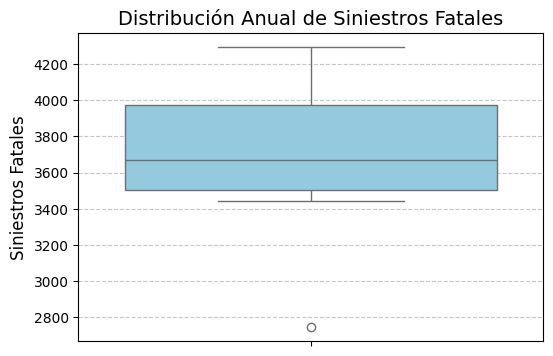

In [ ]:
# Gráfico Boxsplot para ver cuartiles, mediana y posibles outliers
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_siniestros_anio["siniestros_fatales"], color='skyblue')
plt.title('Distribución Anual de Siniestros Fatales', fontsize=14)
plt.ylabel('Siniestros Fatales', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

> La caja central del boxplot muestra dónde se concentra la mayoría de los datos, es decir, el 50% de los años en el período de estudio (2017-2023) tuvieron una cantidad de siniestros fatales entre el primer cuartil (borde inferior de la caja) y el tercer cuartil (borde superior de la caja). La línea dentro de la caja es la mediana, indicando el valor central de siniestros fatales para la mayoría de los años.

> Dispersión de los datos: Los 'bigotes' que se extienden desde la caja nos muestran el rango total de datos, excluyendo los valores atípicos. Esto nos da una idea de cuán dispersos o agrupados están los valores de siniestros fatales anuales. Para este caso, podriamos decir que hay un poco más de dispersión o variabilidad en la dirección del bigote superior (hacia los valores más altos). Para el bigote inferior podemos decir que es más corto, e inmediatamente debajo de él vemos un outlier (el punto suelto). Esto sugiere que la mayoría de los años (después de excluir el 2020 como atípico) tienen valores de siniestros más cercanos entre sí en el extremo inferior de la distribución.
Con respecto al bigote superior, vemos que es más largo. Esto nos indica que los años con un mayor número de siniestros fatales (los valores más altos que no son atípicos) están más dispersos o tienen un rango más amplio. Es decir, hay años donde el número de siniestros fué significativamente más alto que el promedio de la mitad superior de los datos, lo que genera una cola más larga hacia arriba en la distribución.

> El Outlier (Valor Atípico): El punto que se encuentra por debajo del 'bigote' inferior es un valor atípico. Este punto representa el año 2020, donde la cantidad de siniestros fatales fue notablemente más baja que en cualquier otro año del período. Como se mencionó anteriormente, esto se atribuye al confinamiento y las restricciones de movilidad impuestas por la pandemia de COVID-19. La presencia de este valor demuestra que el 2020 fue una excepción significativa en la tendencia histórica de los siniestros (datos).



- Variación porcentual anual de siniestros

In [ ]:
df_siniestros_anio["variacion_porcentual_anual"] = df_siniestros_anio["siniestros_fatales"].pct_change() * 100
df_siniestros_anio

,anio,siniestros_fatales,variacion_porcentual_anual
0,2017,4162,NaN
1,2018,4294,3.171552
2,2019,3671,-14.508617
3,2020,2746,-25.197494
4,2021,3444,25.418791
5,2022,3781,9.785134
6,2023,3567,-5.659878


**Resúmen**

*AÑO* ----> *SINIESTROS* (PORCENTAJE)

2017 ----> 4.162, (Vacío): Inicio del periodo

2018 ----> 4.294  (+3.1%): Pico máximo después del inicio del periodo.

2019 ----> 3.671  (-14.5%): Descenso previo a pandemia

2020 ----> 2.746  (-25.2%): Disminución por Efecto Pandemia.

2021 ----> 3.444  (+25.4%): Recuperación de movilidad, equivalente a un incremento de casos.

2022 ----> 3.781  (+9.7%):  Incremento leve por regreso a niveles pre-pandemia.

2023 ----> 3.567  (-5.6%): Se observa un descenso leve respecto del año anterior.

> En el contexto Inicial (2017-2019), tenemos un periodo de alta siniestralidad con un descenso marcado en 2019.

> Viendo los valores del año 2020, hubo una disminución abrupta del 25.2% producto de la Pandemia COVID-19 y restricciones de movilidad. Con lo cual, los datos sugieren una correlación entre las restricciones de movilidad de 2020 y la baja en la siniestralidad.

> Analizando el efecto rebote, podemos ver que tras el mínimo histórico de 2020 (2.746 casos), hubo un crecimiento del 35% en 2022 respecto al año de pandemia. Esto demuestra que la "mejora" de 2020 fue artificial por asi decirlo, un caso aislado.

> Para el año 2023, los datos consolidados (enero-diciembre) arrojan un total de 3.567 siniestros fatales, lo que representa una disminución del 5,6% en comparación con el año anterior. Tras el incremento observado en la pospandemia (2021-2022), esta caída sugiere una cierta estabilización de la cifra por debajo de los niveles de 2017-2018, retomando la tendencia decreciente que se perfilaba antes del impacto de la crisis sanitaria.

> De esta manera, el cierre de 2023 con 3.567 casos confirma una tendencia a la baja tras el efecto rebote de 2022. Este valor sitúa al 2023 como el segundo año con menor mortalidad de la serie histórica estudiada (excluyendo el año atípico 2020), lo que permite validar hipótesis sobre la eficacia de las políticas de seguridad vial implementadas en el último periodo.

- *Cálculo de la variación total del período (punta a punta)*

Para saber cuánto bajaron los accidentes desde que empezó el estudio hasta que terminó, usamos la fórmula de variación porcentual simple entre el primer año 2017 y el último 2023. Es una fórmula simple que consta de al valor final restarle el valor inicial, luego dividirlo por el inicial y al resultado multiplicarlo por 100, quedando asi:

**Valor Inicial (2017): 4.162**

**Valor Final (2023): 3.567**

Cálculo: $$\frac{3.567 - 4.162}{4.162} \times 100 = {-14,29\%}$$


De esta forma, podemos afirmar que la reducción total de siniestros en el periodo histórico estudiado es del 14,3%.

- Métricas globales clave del Dataset para mayor información

In [ ]:
total_siniestros = df_victimas["id_hecho"].nunique()
total_victimas = len(df_victimas)
cantidad_anios = df_siniestros_anio["anio"].nunique()

promedio_anual_siniestros = total_siniestros / cantidad_anios
promedio_diario_siniestros = total_siniestros / (cantidad_anios * 365)
promedio_victimas_por_siniestro = total_victimas / total_siniestros
promedio_anual_victimas = total_victimas / cantidad_anios


total_siniestros, total_victimas, promedio_anual_siniestros, promedio_diario_siniestros, promedio_victimas_por_siniestro, promedio_anual_victimas


(25665,
 28670,
 3666.4285714285716,
 10.045009784735813,
 1.1170855250340932,
 4095.714285714286)

Pasando en limpio tenemos:
- Total de siniestros: 25.665
- Total de víctimas fatales: 28.670
- Promedio anual de siniestros viales: 3666,4 por año
- Promedio diario de siniestros viales: 10,05 por dia
- Promedio de víctimas por siniestro: 1   (la gran mayoría de los siniestros fatales tienen una sola víctima, pero hay un porcentaje de accidentes múltiples que elevan el valor total).
- Promedio anual de victimas fatales: 4096 por año. (mayor al total de siniestros, ya que como mencionamos puede haber más de una victima involucrada por cada siniestro).

#### *Análisis de las demás variables*

**Franja Horaria**

In [ ]:
df_limpio['Franja_Horaria'].value_counts()

,count
Franja_Horaria,
04. Noche (18-23),8683
02. Mañana (06-11),7865
03. Tarde (12-17),6073
01. Madrugada (00-05),6049


Análisis de los Hallazgos:

> La Noche se considera como horario crítico, ya que cuenta con 8.683 víctimas, la franja horaria de 18:00 a 23:59 es la más peligrosa. Esto se lo podría asociar a la fatiga tras la jornada laboral, la reducción de visibilidad, el aumento del tráfico en la hora pico de regreso o el incumplimiento de reglas de tránsito producto del horario.

> El riesgo de la Mañana, con una franja horaria de 06:00 a 11:59 ocupa el segundo lugar (7.865) casos. Aquí entran los siniestros de camino al trabajo y, muy importante, los accidentes de quienes regresan de salidas nocturnas (especialmente los fines de semana).

> La Tarde y la Madrugada, curiosamente tienen valores practicamente similares (aprox 6.000). Sin embargo, la Madrugada suele ser mucho más alarmante a pesar de contar con un flujo de vehículos drásticamente menor (hay menos autos circulando que a la tarde, pero casi la misma cantidad de muertos).Este patrón sugiere que factores como el cansancio, la velocidad excesiva/ exceso de alcohol y la menor visibilidad nocturna son determinantes en la gravedad de los siniestros.


**Meses**

In [ ]:
df_limpio["mes_num"].value_counts()    # Para ordenarlo de enero .... diciembre, uso .sort_index()

,count
mes_num,
12,2736
1,2684
3,2447
10,2443
7,2416
2,2389
8,2338
9,2336
11,2293


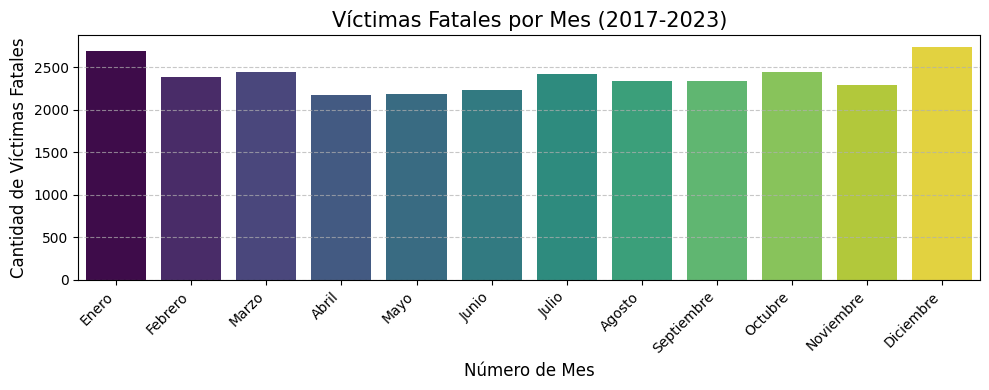

In [ ]:
# Gráfico de barras para víctimas fatales por mes

# Calculamos el número de víctimas fatales por mes
df_victimas_mes = df_limpio.groupby('mes_num').size().reset_index(name='victimas_fatales_mes')

plt.figure(figsize=(10, 4))
sns.barplot(x='mes_num', y='victimas_fatales_mes', data=df_victimas_mes, palette='viridis', hue='mes_num', legend=False)
plt.title('Víctimas Fatales por Mes (2017-2023)', fontsize=15)
plt.xlabel('Número de Mes', fontsize=12)
plt.ylabel('Cantidad de Víctimas Fatales', fontsize=12)
plt.xticks(ticks=range(0, 12), labels=['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'], rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

*Análisis de los Datos (Hallazgos):*

> Se observa un pico durante el Verano, donde en Diciembre se presentan (2.736) victimas y Enero (2.684), liderando la tabla. Esto coincide con el mayor flujo de vehículos en rutas nacionales producto de las vacaciones de verano y los viajes por las fiestas de fin de año.

> En Marzo con (2.447) casos, aparece en tercer lugar. Podríamos plantear como hipótesis, que se debe al regreso masivo de las vacaciones y el inicio del ciclo lectivo, lo que aumenta drásticamente el tráfico urbano.

> Con respecto al periodo estacional de Otoño-Invierno, Abril cuenta con (2.176) casos, Mayo (2.180) y Junio (2.232) son los meses con menos siniestros. Es un periodo de transición donde la movilidad suele ser más rutinaria y menos ligada a viajes de larga distancia. Luego esto se eleva un poco en los meses de Julio-Agosto, seguramente asociado al receso de vacaciones de invierno.

**Tipo de lugar y los modos en que se produjeron los siniestros con victimas fatales**

- Observamos los valores únicos de las columnas : "tipo_lugar", "modo_produccion_hecho" y "modo_produccion_hecho_ampliada"

In [ ]:
df_limpio["tipo_lugar"].value_counts()

,count
tipo_lugar,
Calle,11191
Ruta Nacional,8485
Ruta Provincial,6012
Sin determinar,1308
Autopista Provincial,589
Autovía,546
Autopista Nacional,539


In [ ]:
df_limpio["modo_produccion_hecho"].value_counts()

,count
modo_produccion_hecho,
Colisión vehículo-vehículo,15413
Vuelco-Despistes,5694
Colisión vehículo-persona,3499
Colisión vehículo-objeto,2027
Sin determinar,1355
Otro,682


In [ ]:
df_limpio["modo_produccion_hecho_ampliada"].value_counts()

,count
modo_produccion_hecho_ampliada,
Colisión vehículo-vehículo,15323
Vuelco-despistes,5672
Colisión vehículo-persona,3498
Colisión vehículo-objeto,2026
Sin determinar,1355
Caída del ocupante,449
Colisión vehículo-animal,198
Colisión múltiple,84
Otro (especificar),14


*Análisis de los Hallazgos*

1. Infraestructura y Entorno (tipo_lugar)

> **Predominación de Urbano vs. Interurbano:** Las Calles con (11.191) casos lideran la siniestralidad, lo cual es lógico por la densidad de cruces y el volumen vehicular que circula por esos lugares. Sin embargo, si agrupamos las Rutas Nacionales y Provinciales contamos con (14.497) victimas representando una cifra alarmante, donde vemos que la mayor cantidad de muertes ocurre en entornos de alta velocidad, a pesar de haber menos tráfico que en las ciudades.

> **Autopistas y Autovías:** En relación a las Autopistas (Nacionales, Provinciales y Autovías) es notable que sumen menos de 1.700 casos. Esto confirma que, aunque se circula a alta velocidad, la infraestructura de carriles separados promueve un ambiente más seguro que las rutas convencionales.

> Por último, hay un determinado porcentaje de casos que no se han determinado (	1.308)

2. Modo del Siniestro (modo_produccion_hecho)

> **El choque entre vehiculos como factor principal:** La Colisión vehículo-vehículo con (15.413) casos, representa más del 50% de los casos. Esto sugiere que puede deberse a problemas de sobrepaso, la escasa distancia entre un vehiculo y otro o fallas en las intersecciones.

> **Pérdida de control:** Los Vuelcos y Despistes con (5.694) casos ocupan el segundo lugar. Estos hechos podría estar asociado al cansancio, exceso de velocidad o mal estado de las banquinas, especialmente en las rutas.

> **Vulnerabilidad del Peatón:** La Colisión vehículo-persona con (3.499) casos es el tercer factor. Es un número bastante importante a tener en cuenta y que podría cruzarse con la variable "Calle" para comprender mejor el riesgo urbano.

> En menor proproción se encuentra la colisión vehículo-objeto con (2.027) casos, lo cual podría representar causas de distracción, cansancio, exceso de velocidad o consumo de alcohol.

3. Detalle del Modo (modo_produccion_hecho_ampliada)
Esta columna valida a la anterior, pero añade algunos rasgos importantes (mayor consistencia de los datos):

> **Caída del ocupante (449):** Esto es un dato clave si tenemos en cuenta para las motos (representa  aquellas personas que mueren sin que otro vehículo las choque).

> **Tracción a sangre y animales (211 casos sumados):** Aunque son pocos, representan riesgos específicos de zonas rurales o periurbanas. Cabe aclarar que en algunos lugares este tipo de medio ya está prohibido.


*Cruce: Peatones y Calles*

> Este cruce visualizará la vulnerabilidad en zonas urbanas. Vamos a ver si los accidentes (Colisión vehículo-persona) ocurren mayormente en Calles.

In [ ]:
# Tabla cruzada entre Tipo de Lugar y Modo de Producción
cruce_peaton_calle = pd.crosstab(df_limpio['tipo_lugar'], df_limpio['modo_produccion_hecho'])

# Seleccionamos solo la columna de colisión para analizarla mejor
colision = cruce_peaton_calle['Colisión vehículo-persona'].sort_values(ascending=False)
colision

,Colisión vehículo-persona
tipo_lugar,
Calle,1958
Ruta Nacional,719
Ruta Provincial,399
Sin determinar,180
Autopista Provincial,90
Autovía,88
Autopista Nacional,65


> A simple vista vemos que, los 3.499 colisiones totales vehiculo- peaton que teníamos en la columna modo_produccion_hecho, acabamos de demostrar que 1.958 ocurren en Calles. Es decir, el 56% de los peatones mueren en el entorno urbano, algo que era previsto pero que implica un riesgo urbano.

> Por lo tanto, casi 6 de cada 10 atropellamientos ocurren en las calles. Esto indica que el conflicto vehículo-peatón es un problema de diseño urbano, puede ser por falta de sendas peatonales o incumplimientos de las mismas como los semáforos para peatones o exceso de velocidad en avenidas.

> Con respecto a las Rutas y Autopistas (peligro de la alta velocidad): Es muy llamativo encontrar 153 muertes en Autopistas (90+65). En teoría, un peatón no debería estar cruzando en una autopista. Esto nos permite pensar en si: ¿son personas cruzando por lugares no habilitados o trabajadores viales? Es un dato para tenerlo en cuenta.

**Distribución geográfica (provincias)**

- Provincias y los diferentes tipos de vehiculos

In [ ]:
for col in ["provincia_nombre", "victima_vehiculo", "victima_vehiculo_ampliado"]:
  print(f"\nColumna: {col}")
  print(df_limpio[col].value_counts())


Columna: provincia_nombre
provincia_nombre
Buenos Aires                                             7420
Córdoba                                                  2702
Santa Fe                                                 2592
Tucumán                                                  1865
Santiago del Estero                                      1543
Misiones                                                 1534
Chaco                                                    1260
Salta                                                    1147
Entre Ríos                                               1017
Mendoza                                                   969
Ciudad Autónoma de Buenos Aires                           786
Formosa                                                   680
Corrientes                                                632
San Juan                                                  631
Jujuy                                                     573
San Luis                  

*Análisis de Vehículos y Provincias*






> **Aclaración**: Para la distribución general por tipo de vehículo se utiliza la variable 'victima_vehiculo_ampliado' (ya que cuenta con mayor detalle y tipos). Para realizar los cruces con otras variables (como sexo/edad) se utilizará la variable 'victima_vehiculo' por tratarse de una versión más resumida, que mejora la interpretabilidad de las tablas cruzadas evitando una alta fragmentación de las categorías (tablas cruzadas más legibles).

> Por otra parte, vemos que en 'victima_vehiculo'  aparece "Peatón" (494 casos), mientras que en la ampliada aparece "Sin vehículo" (2815).
Eso no necesariamente está mal, sino que son definiciones distintas. Una es más resumida, otra agrupa más casos (probablemente peatón y otros). Por eso justamente usamos la variable ampliada para el conteo general y la resumida para cruces, donde "peatón" puede ser útil como categoría interpretativa.

In [ ]:
# Top 5 Provincias con más víctimas
top_provincias = df_limpio['provincia_nombre'].value_counts().head(5)

# Distribución por Tipo de Vehículo de la Víctima
#tipo_vehiculo = df_limpio['victima_vehiculo'].value_counts()
# Distribución por Tipo de Vehículo (ampliado) de la Víctima
tipo_vehiculo_ampliado = df_limpio['victima_vehiculo_ampliado'].value_counts()

print("--- Top 5 Provincias ---")
print(top_provincias)
#print("\n--- Victimas por Vehículo ---")
#print(tipo_vehiculo)
print("\n--- Victimas por Vehículo ---")
print(tipo_vehiculo_ampliado)

--- Top 5 Provincias ---
provincia_nombre
Buenos Aires           7420
Córdoba                2702
Santa Fe               2592
Tucumán                1865
Santiago del Estero    1543
Name: count, dtype: int64

--- Victimas por Vehículo ---
victima_vehiculo_ampliado
Motocicleta               11982
Automóvil                  7496
Sin vehiculo               2815
Camioneta                  2119
Sin determinar             1817
Bicicleta                  1119
Camión                      651
Ciclomotor                  242
Micro larga distancia       119
Colectivo                   103
Tren                         53
Tractor                      51
Tracción a sangre            27
Cuatriciclo / Triciclo       22
Otro                         17
Ambulancia                   15
Maquinaria                   13
Arenero/Karting/Buggy         4
Grúa                          3
Acoplado                      1
Autobomba                     1
Name: count, dtype: int64


> Al analizar la distribución del lugar de los hechos, se observa una fuerte concentración en la provincia de Buenos Aires, seguida por Córdoba y Santa Fe, con valores cercanos. Esto podría estar asociado a la densidad poblacional del lugar y al tamaño del parque automotor de esas jurisdicciones.

> En cuanto a los medios de transporte involucrados, se identifica que las motos  representan el mayor porcentaje de víctimas fatales. Este dato es crítico ya que permite segmentar el riesgo y concluir que los usuarios de motos son el grupo de mayor vulnerabilidad en la vía pública durante el periodo 2017-2023, seguido de automóviles con un valor de 7.496 victimas.

**Género de las victimas**

In [ ]:
for col in ["victima_sexo"]:
   print(f"\nColumna: {col}")
   print(df_limpio[col].value_counts())


Columna: victima_sexo
victima_sexo
Masculino         22080
Femenino           6017
Sin determinar      573
Name: count, dtype: int64


> Es evidente la diferencia de que el género masculino es la categoría que predomina como victima en siniestros viales.

*Análisis del cruce entre Género y Tipo de Vehículo para mostrar patrones muy claros, como por ejemplo, si los hombres fallecen más en moto o viceversa.*

In [ ]:
# Tabla cruzada de Género y Vehículo
cruce_perfil = pd.crosstab(df_limpio['victima_vehiculo'], df_limpio['victima_sexo'])
cruce_perfil

victima_sexo,Femenino,Masculino,Sin determinar
victima_vehiculo,,,
Automóvil,2309,5047,140
Bicicleta,168,941,10
Camioneta,504,1580,35
Camión,23,612,16
Ciclomotor,50,180,12
Colectivo,35,65,3
Micro larga distancia,61,58,0
Motocicleta,1588,10326,68
No corresponde,868,1972,9


Análisis de los Hallazgos

> La Motocicleta como vehiculo de máximo riesgo, cuenta con 11.982 víctimas totales, de las cuales, 10.326 son de género masculino, 1.588 femenino y 68 sin género determinado. Con estos valores podemos apreciar que la moto supera ampliamente al automóvil, y es el vehículo con la mayor brecha de género y la mayor mortalidad absoluta.

> Respecto a la diferencia de Género, si comparamos los valores de la tabla, el género Masculino predomina en todas las categorías (excepto en "Micro larga distancia", donde están casi iguales). Esto sugiere que el perfil de riesgo en la vía pública está fuertemente vinculado al genero masculino.

> Considerando la excepcion de la categoria de Micro a larga distancia, es el único vehículo donde hay más mujeres fallecidas (61) que hombres (58). Esto es un hallazgo atípico que es bueno  mencionar como una excepción a la regla general que venimos viendo.

**Edad**

In [ ]:
for col in ["victima_tr_edad"]:
  print(f"\nColumna: {col}")
  print(df_limpio[col].value_counts().head(20))



Columna: victima_tr_edad
victima_tr_edad
20-24             3851
25-29             3158
30-34             2540
15-19             2457
35-39             2335
Sin determinar    2039
40-44             2027
45-49             1705
50-54             1586
60-64             1351
55-59             1298
65-69             1045
70-74              851
75-79              571
10-14              483
4 o menos          431
80-84              364
5-9                345
85-89              179
90 y más            54
Name: count, dtype: int64



*Análisis de Edad : La Juventud en posible riesgo*

Este riesgo es un patrón clásico en seguridad vial mundial, pero nuestros números lo confirman para Argentina también.

> **Pico de Mortalidad en jóvenes:** La franja de 20 a 24 años es la más afectada con (3.851) victimas, seguida inmediatamente por la de 25 a 29 con (3.158).

> **Más jóvenes:** Si sumamos desde los 15 hasta los 39 años, obtenemos la gran mayoría de las víctimas. Esto significa que los siniestros viales son la principal causa de muerte de personas en su etapa más productiva.

> **Dato no menor:** Los menores de 14 años suman más de 1.200 casos. Es un número bajo comparado con los jóvenes, pero muy relevante para tener en cuenta las políticas de seguridad infantil (por ejemplo sillas de retención, controlar que esten ubicados de forma reglamentaria).

*Análisis del cruce entre Edad de la victima y su Género*


- Para profundizar el perfil demográfico, se analiza la distribución por sexo en cada rango etario, observando una prevalencia masculina crítica en todas las etapas de la vida, especialmente en la juventud.

In [ ]:
# Tabla cruzada de edad de victima y Género
cruce_sexo_edad = pd.crosstab(df_limpio['victima_tr_edad'], df_limpio['victima_sexo'])
cruce_sexo_edad

victima_sexo,Femenino,Masculino,Sin determinar
victima_tr_edad,,,
10-14,175,300,8
15-19,521,1911,25
20-24,631,3183,37
25-29,547,2582,29
30-34,435,2076,29
35-39,442,1866,27
4 o menos,170,250,11
40-44,351,1660,16
45-49,348,1333,24


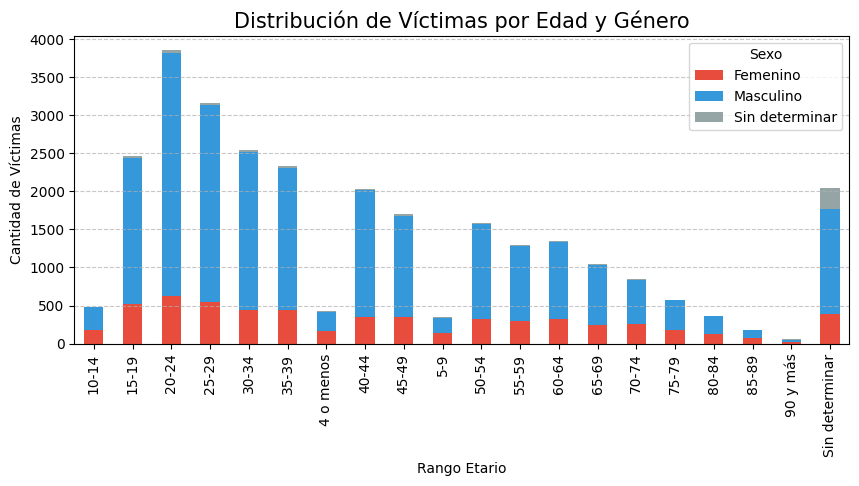

In [ ]:
# Gráfico de relación edad y género de la víctima
cruce_sexo_edad.plot(kind='bar', stacked=True, figsize=(10,4), color=['#e74c3c', '#3498db', '#95a5a6'])
plt.title('Distribución de Víctimas por Edad y Género', fontsize=15)
plt.xlabel('Rango Etario')
plt.ylabel('Cantidad de Víctimas')
plt.legend(title='Sexo')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Hallazgos claves:

> **Predominio Masculino:** La barra azul (Masculino) domina absolutamente en todos los rangos etarios. Esto indica que la siniestralidad fatal en Argentina tiene una marcada de género fuertemente inclinada a masculino, como lo estudiamos anteriormente.

> **El Pico de los 20-24:** Es el momento donde la brecha es más alta. Hay muchísimos más hombres que mujeres fallecidos en esa edad.

> **En Edad Avanzada:** Como dijimos, prevalece una marcada diferencia de género en la juventud, con una prevalencia masculina absoluta en los siniestros fatales. Sin embargo, esta tendencia tiende a igualarse en los rangos de edad avanzada (80 años en adelante). En esta etapa, la diferencia entre hombres y mujeres se reduce significativamente, lo que sugiere una transición hacia perfiles de riesgo comunes, como la vulnerabilidad del peatón en la vía pública.

*Análisis del cruce entre Edad de la victima y Vehiculo*

In [ ]:
# Tabla cruzada de edad de victima y Vehículo
cruce_edad_vehiculo = pd.crosstab(df_limpio['victima_vehiculo'], df_limpio['victima_tr_edad'])
cruce_edad_vehiculo

victima_tr_edad,10-14,15-19,20-24,25-29,30-34,35-39,4 o menos,40-44,45-49,5-9,50-54,55-59,60-64,65-69,70-74,75-79,80-84,85-89,90 y más,Sin determinar
victima_vehiculo,,,,,,,,,,,,,,,,,,,,
Automóvil,140,388,764,793,663,666,151,566,456,138,454,388,427,349,274,195,96,46,16,526
Bicicleta,43,51,77,62,51,61,9,66,70,20,74,96,101,101,89,56,24,15,2,51
Camioneta,33,72,131,187,170,170,40,190,178,41,167,132,150,132,84,59,31,13,3,136
Camión,1,15,40,62,91,75,3,65,79,3,52,51,33,17,7,1,2,1,0,53
Ciclomotor,2,18,42,37,22,16,1,12,15,1,16,10,8,2,3,3,0,0,0,34
Colectivo,6,8,7,10,9,7,1,5,8,1,7,5,2,5,3,3,4,1,0,11
Micro larga distancia,2,4,7,6,8,7,2,7,9,1,7,3,9,5,2,2,1,1,1,35
Motocicleta,165,1589,2395,1683,1260,1037,54,876,651,41,571,395,368,212,131,59,28,7,0,460
No corresponde,56,182,198,165,140,158,136,138,126,74,133,152,163,164,186,151,136,77,24,290


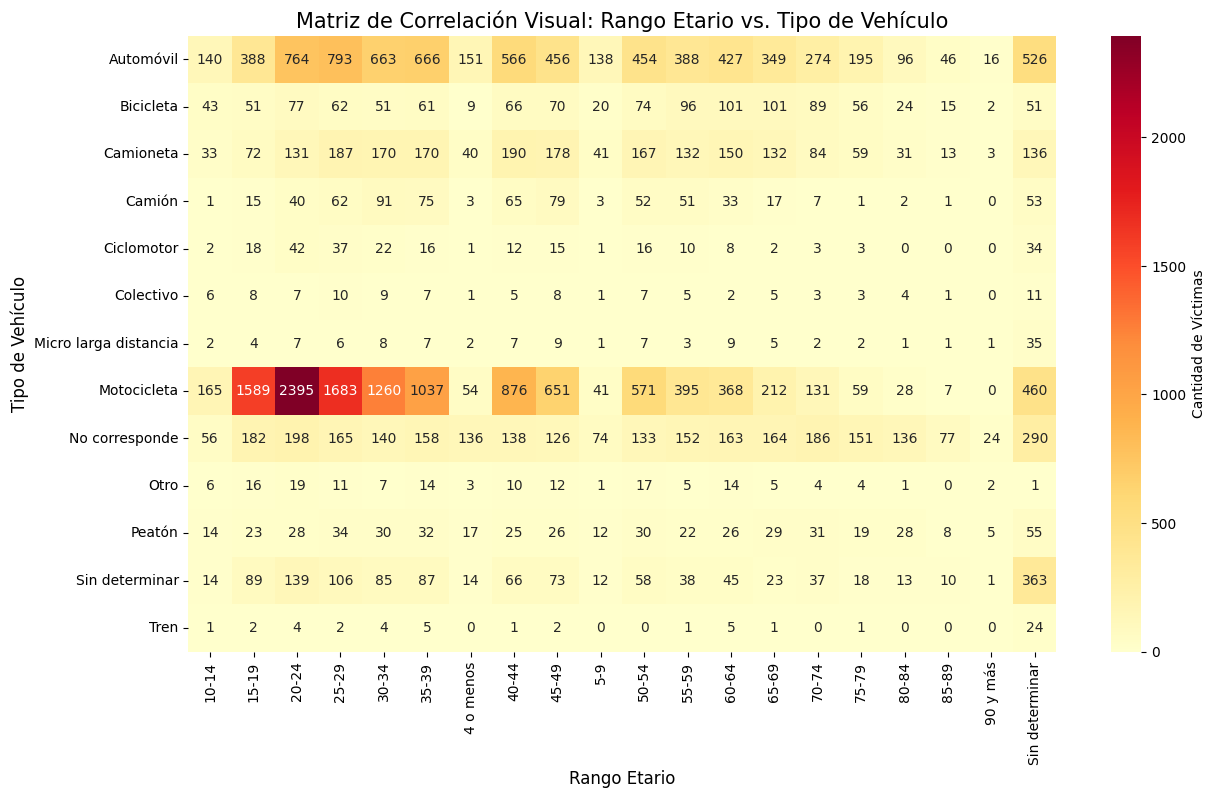

In [ ]:
# Matriz de correlación - Mapa de calor
# Usamos la tabla cruzada de edad de victima y Vehículo:
plt.figure(figsize=(14, 8))
sns.heatmap(cruce_edad_vehiculo, annot=True, fmt="d", cmap="YlOrRd", cbar_kws={'label': 'Cantidad de Víctimas'})
plt.title('Matriz de Correlación Visual: Rango Etario vs. Tipo de Vehículo', fontsize=15)
plt.xlabel('Rango Etario', fontsize=12)
plt.ylabel('Tipo de Vehículo', fontsize=12)
plt.show()

Hallazgos claves:

> **La enorme cantidad de casos de la Moto en Jóvenes:** Si observamos la fila de Motocicleta, el salto de la franja 15-19 (1.589) a la de 20-24 (2.395) es importante. Es el valor más alto de toda la tabla por lejos. Esto indica que el primer vehículo de movilidad propia (la moto) es el factor de riesgo número uno para el joven adulto en Argentina. Algo que habiamos visto en el análisis de tipo de vehículo.

> **Automóvil vs. Camioneta en adultos:** Si nos fijamos en el Automóvil, la distribución es más pareja entre los 20 y los 44 años. Pero en Camioneta, los valores se mantienen altos y parejos incluso en edades más avanzadas (40-44 años tiene 190 casos), lo que podría asociarse a vehículos de trabajo o de uso rural.

> **El Peatón en edad avanzada:** Si bien la cantidad de peatones es menor, observamos que en edades avanzadas, por ejemplo 70-74 años, los valores de Peatón se mantienen estables mientras que otros vehículos bajan (como en motocicleta). Esto refuerza la idea de la fragilidad y vulnerabilidad del adulto mayor al caminar por la calle.

**Condiciones Climáticas**

In [ ]:
for col in ["clima_condicion"]:
  print(f"\nColumna: {col}")
  print(df_limpio[col].value_counts().head(20))



Columna: clima_condicion
clima_condicion
Bueno             15542
Sin determinar    11589
Nublado             645
Lluvia              616
Llovizna            210
Otra condición       44
Nieve                18
Granizo               6
Name: count, dtype: int64


*Análisis del Clima: : El mito de la lluvia*  (Visualizado previamente)

> **Clima Bueno (15.542):** La gran mayoría de los accidentes fatales ocurren con buen tiempo.
Esto refleja cierta paradoja, ya que demuestra que el conductor tiende a ser más imprudente (manejo a más velocidad, con menos atención) cuando el clima es favorable. Mientras que bajo la lluvia o nieve, se suele manejar con más precaución.

> **A tener en cuenta:** el valor "Sin determinar" con (11.589) casos es muy alto. Esto podría significar que en muchos partes policiales no se registró la condición climática a menos que fuera algo extremo (como una tormenta).

#### MINERÍA DE DATOS

**Aplicación de Series Temporales (tendencia y estacionalidad)**

> Como nuestro fenómeno analizado refleja un comportamiento temporal(variaciones mensuales y anuales) y el objetivo del proyecto es identificar patrones sin la obligatoriedad de construir un modelo predictivo, por ende, se aplica la técnica de análisis de series temporales sobre el conteo mensual de víctimas fatales. En otras palabras, usamos series temporales para detectar patrones con tendencia, estacionalidad y suavizado sin predecir nada.

> Para ello, se construye una serie temporal mensual a partir de las variables 'anio' y 'mes_num', asignando cada registro al primer día del mes (fecha_mes). La serie resultante representará el número de víctimas fatales por mes durante el período 2017-2023, con un total de 84 observaciones (12 meses x 7 años del periodo comprendido).




- Construcción de serie temporal de victimas fatales mensuales

In [ ]:
# Serie temporal

df_st = df_limpio.copy()

# Creo una fecha mensual (ej: primer día de cada mes)
df_st["fecha_mes"] = pd.to_datetime(df_st["anio"].astype(str) + "-" + df_st["mes_num"].astype(str) + "-01",errors="coerce")

# Serie mensual: cantidad de víctimas (cada fila = víctima)
serie_mensual = (
    df_st.dropna(subset=["fecha_mes"])
         .set_index("fecha_mes")
         .sort_index()
         .resample("MS")   # Month Start: acá se agrupa los datos por el inicio de cada mes.
         .size()           # Dentro de cada grupo mensual creado por resample, cuenta el número de filas (que representan a las víctimas individuales).
         .rename("victimas_fatales")
)

serie_mensual.head(50), serie_mensual.shape


(fecha_mes
 2017-01-01    408
 2017-02-01    389
 2017-03-01    367
 2017-04-01    337
 2017-05-01    355
 2017-06-01    388
 2017-07-01    373
 2017-08-01    394
 2017-09-01    406
 2017-10-01    449
 2017-11-01    412
 2017-12-01    452
 2018-01-01    439
 2018-02-01    438
 2018-03-01    462
 2018-04-01    427
 2018-05-01    402
 2018-06-01    405
 2018-07-01    444
 2018-08-01    318
 2018-09-01    375
 2018-10-01    302
 2018-11-01    346
 2018-12-01    445
 2019-01-01    335
 2019-02-01    308
 2019-03-01    374
 2019-04-01    319
 2019-05-01    309
 2019-06-01    346
 2019-07-01    364
 2019-08-01    365
 2019-09-01    362
 2019-10-01    355
 2019-11-01    357
 2019-12-01    395
 2020-01-01    359
 2020-02-01    319
 2020-03-01    246
 2020-04-01    124
 2020-05-01    172
 2020-06-01    173
 2020-07-01    217
 2020-08-01    224
 2020-09-01    249
 2020-10-01    263
 2020-11-01    277
 2020-12-01    360
 2021-01-01    342
 2021-02-01    297
 Freq: MS, Name: victimas_fatales, dtyp


> La serie mensual de victimas fatales muestra variaciones a lo largo del tiempo. Hay un marcado descenso en el año 2020, seguido de una recuperación gradual en los años posteriores. Este comportamiento sugiere hay un efecto directo asociado a cambios en la movilidad posiblemente relacionado a las restricciones impuestas durante la pandemia de COVID-19 en ese período (lo que notamos anteriormente).




- Suavizado para detectar las tendencias (media móvil)

> Se aplica medias móviles sobre la serie temporal mensual de víctimas fatales para reducir o suavizar las fluctuaciones/variaciones de corto plazo y también para identificar la tendencia subyacente de esta serie (patrón de largo plazo ):
la *Media Movil MM(3)* se encarga de suavizar las variaciones de corto plazo (trimestre) y la *Media Movil MM(12)*, es la que suaviza el ruido anual y permite ver mejor la tendencia de largo plazo.

> La visualización en conjunto (serie original + MM12) nos permite identificar cambios estructurales en el tiempo.

Cálculo de las dos medias moviles:

> Una media móvil con ventana de tiempo de tamaño 3 define el tamaño de la ventana de tiempo. Con lo cual, para este caso la media se calculará usando los 3 meses más recientes. Y con min_periods=1 significa que para calcular la media móvil, necesitamos al menos 1 dato dentro de la ventana. Esto es importante para los primeros meses de la serie, donde no hay 3 meses anteriores completos, permitiendo que la media móvil comience desde el primer mes en lugar de tener valores NaN. por último calculamos el promedio de los valores dentro de cada ventana. El resultado lo guardamos en una nueva columna del Df st llamada mm_3 (media móvil de 3 meses)

> Lo mismo hacemos para el cálculo de la otra media móvil. Funciona exactamente igual, lo único es que calcula una media móvil de 12 meses (window=12). Una media móvil de 12 meses es útil para identificar tendencias más a largo plazo y para suavizar la estacionalidad anual (ya que cada punto de esta media móvil incluye datos de un año completo).


In [ ]:
st = serie_mensual.to_frame()            # Convertimos la serie creada en un df

st["mm_3"] = st["victimas_fatales"].rolling(window=3, min_periods=1).mean()     # Cálculo de media movil usando los 3 meses más recientes.
st["mm_12"] = st["victimas_fatales"].rolling(window=12, min_periods=1).mean()   # Cálculo de media móvil usando los 12 meses.

st.head(15)

,victimas_fatales,mm_3,mm_12
fecha_mes,,,
2017-01-01,408,408.000000,408.000000
2017-02-01,389,398.500000,398.500000
2017-03-01,367,388.000000,388.000000
2017-04-01,337,364.333333,375.250000
2017-05-01,355,353.000000,371.200000
2017-06-01,388,360.000000,374.000000
2017-07-01,373,372.000000,373.857143
2017-08-01,394,385.000000,376.375000
2017-09-01,406,391.000000,379.666667


- Estacionalidad simple (promedio por mes del año)

> En esta instancia calculamos el promedio por mes del año de las víctimas fatales para identificar meses con mayor riesgo, independientemente del año. Esto nos ayuda a identificar si hay meses específicos que tienen más o menos siniestros, sin tener en cuenta el año.

In [ ]:
# Serie con el promedio de víctimas fatales para cada uno de los 12 meses del año

st_est = st.copy()
st_est["mes"] = st_est.index.month        # extrae el número del mes (del 1 al 12) de cada fecha en el índice y se guarda en mes.

estacionalidad = st_est.groupby("mes")["victimas_fatales"].mean().round(2)    # agrupamos los datos por el mes para todos los años y  calculamos el promedio de victimas para grupo. Redondeo a 2 dec.
estacionalidad

,victimas_fatales
mes,
1,383.43
2,341.29
3,349.57
4,310.86
5,311.43
6,318.86
7,345.14
8,334.00
9,333.71


>  En los resultados, vemos que diciembre (390.86) y enero (383.43) presentan los promedios más altos, lo que sugiere un patrón estacional consistente (posiblemente asociado a vacaciones, mayor circulación y eventos). En esos meses, las personas suelen estar en épocas de vacaciones y la circulación suele aumentar. Por ende, hay mayor probabilidad de victimas fatales por incidentes (Lo que notamos anteriormente en EDA).

>Los meses que muestran los promedios más bajos son los meses de abril (310.86) y mayo (311.43), lo que sugiere que estos meses son los menos peligrosos (menos victimas fatales posiblemente por época de rutina diaria).

**Evaluación sencilla (sin emplear modelo predictivo)**


> Para cuantificar el efecto del suavizado, se compara la variabilidad (desvío estándar) de la serie original con la serie suavizada con media móvil MM(12):

In [ ]:
std_original = st["victimas_fatales"].std()
std_mm12 = st["mm_12"].std()

print("Desvío estándar original:", round(std_original, 2))
print("Desvío estándar con suavizado media móvil MM(12):", round(std_mm12, 2))
print("Reducción de variabilidad:", round((1 - std_mm12/std_original)*100, 2), "%")


Desvío estándar original: 63.93
Desvío estándar con suavizado media móvil MM(12): 46.61
Reducción de variabilidad: 27.1 %


> Podemos apreciar que la media móvil de 12 meses reduce la variabilidad del conteo mensual.

> Con un desvío estándar original de 63.93 y un desvío estándar con MM(12) de 46.61, obtuvimos una reducción de variabilidad del 27.1%
Esto nos muestra que el suavizado permite observar con mayor claridad la tendencia y patrones estacionales sin la necesidad de recurrir a modelos predictivos.

> Conclusión: el suavizado anual reduce el "ruido" mensual en un 27,1%, permitiendo observar con más claridad la tendencia general (descenso 2019, quiebre 2020, recuperación 2021-2022).

- Visualización de los resultados de la serie temporal

Text(0, 0.5, 'Cantidad de víctimas')

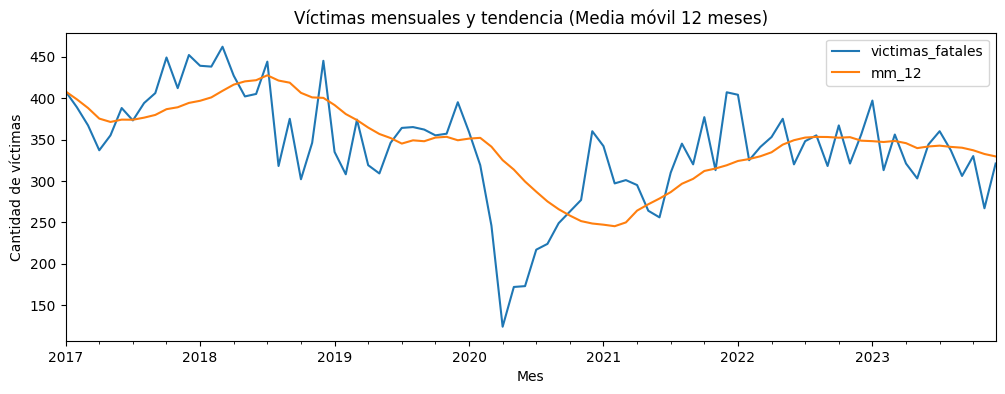

In [ ]:
ax = st[["victimas_fatales", "mm_12"]].plot(figsize=(12,4))
ax.set_title("Víctimas mensuales y tendencia (Media móvil 12 meses)")
ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad de víctimas")

**Interpretación**
> La serie mensual de victimas fatales muestra fluctuaciones a lo largo del tiempo. Hay un descenso marcado en 2020, seguido de una recuperación gradual en los años posteriores. Este comportamiento podría estar asociado a cambios en la movilidad  y las restricciones impuestas durante la pandemia de COVID-19 en ese período.
>
> Especificando más, la restricción total de circulación y aislamiento, que tuvieron su pico alrededor del mes de abril de 2020, coinciden temporalmente con una fuerte caída en el número de víctimas fatales, con los valores más bajos registrados durante los meses de cuarentena más estricta. Posteriormente, a medida que el aislamiento se fue flexibilizando en la segunda mitad de 2020 y en 2021, se observa una paulatina recuperación en los siniestros fatales.

> La media móvil de 12 meses (MM(12)) es fundamental para evidenciar la tendencia subyacente de esta serie (patrón de largo plazo ), "limpiándola" de sus componentes estacionales y de ruido mensual. Se observa:
>
> - 2017-2018: Un nivel de siniestralidad alto y relativamente estable.
>- 2019: Un descenso gradual que marcaba una tendencia a la baja antes de la pandemia.
>- 2020: Un quiebre abrupto y un mínimo histórico debido a las restricciones.
>- 2021-2022: Una subida progresiva en el número de víctimas a medida que la movilidad se normalizaba.
>- 2023: Una estabilización, con un leve descenso, que sugiere un regreso a una tendencia de mejora en la siniestralidad, posiblemente por debajo de los niveles pre-pandemia de 2017-2018.

> El suavizado mediante la MM(12) reduce la variabilidad mensual en un 27,1% (el desvío estándar pasa de 63.93 a 46.61), lo que facilita la interpretación de esta tendencia a largo plazo sin necesidad de recurrir a modelos predictivos complejos.






#### VERIFICACIÓN FINAL DEL DATASET LIMPIO

- Realizo un chequeo final antes de continuar a las visualizaciones en Streamlit, para así evitar errores en los gráficos, categorías mal ordenadas, datos basura o problemas al filtrar.

In [ ]:
df_limpio.columns.tolist()

['id_hecho',
 'tipo_persona',
 'tipo_persona_id',
 'anio',
 'provincia_nombre',
 'tipo_lugar',
 'modo_produccion_hecho',
 'modo_produccion_hecho_ampliada',
 'victima_sexo',
 'victima_tr_edad',
 'victima_vehiculo',
 'victima_vehiculo_ampliado',
 'clima_condicion',
 'latitud',
 'longitud',
 'Franja_Horaria',
 'mes_num']

In [ ]:
df_limpio.shape

(28670, 17)

- Analizo el porcentaje de valores nulos. Las variables latitud y longitud si deberian contar con algunos valores faltantes ya que anteriormente lo aclaramos. Las demás no deberían contar.

In [ ]:
df_limpio.isna().mean().sort_values(ascending=False)

,0
latitud,0.385246
longitud,0.385246
id_hecho,0.000000
tipo_persona,0.000000
tipo_persona_id,0.000000
tipo_lugar,0.000000
modo_produccion_hecho,0.000000
anio,0.000000
provincia_nombre,0.000000
victima_sexo,0.000000


> Efectivamente, ninguna columna del dataframe limpio cuenta con valores nulos, salvo latitud y longitud.

- Visualizo todos los valores únicos de todas las columnas del dataframe limpio, para verificar que esté correcto su contenido.

In [ ]:
for col in [
    "id_hecho",
    "tipo_persona",
    "tipo_persona_id",
    "anio", "mes_num",
    "provincia_nombre",
    "tipo_lugar",
    "modo_produccion_hecho",
    "modo_produccion_hecho_ampliada",
    "victima_sexo",
    "victima_tr_edad",
    "victima_vehiculo",
    "victima_vehiculo_ampliado",
    "Franja_Horaria",
    "clima_condicion",
    "latitud",
    "longitud"
]:
    print(f"\n--- {col.upper()} ---")
    print(df_limpio[col].value_counts().head(25))



--- ID_HECHO ---
id_hecho
16276    16
16355    15
28651    15
13205    13
34581    11
28217    10
21200    10
28299     8
21128     8
30152     7
47788     7
36024     6
25837     6
40363     6
17016     6
17755     6
28183     6
24644     6
13206     6
22308     6
28139     6
39611     6
40922     6
34608     6
29036     5
Name: count, dtype: int64

--- TIPO_PERSONA ---
tipo_persona
Víctima    28670
Name: count, dtype: int64

--- TIPO_PERSONA_ID ---
tipo_persona_id
Víctima idRegistro  58582    1
Víctima idRegistro 16629     1
Víctima idRegistro 16630     1
Víctima idRegistro 16631     1
Víctima idRegistro 16632     1
Víctima idRegistro 16641     1
Víctima idRegistro 16642     1
Víctima idRegistro 16643     1
Víctima idRegistro 16645     1
Víctima idRegistro 16646     1
Víctima idRegistro 16647     1
Víctima idRegistro 16648     1
Víctima idRegistro 16649     1
Víctima idRegistro 16650     1
Víctima idRegistro  58579    1
Víctima idRegistro  58575    1
Víctima idRegistro  58593    1
V

- Reviso si hay duplicados

In [ ]:
df_limpio.duplicated().sum()

np.int64(0)

- Muestro un resumen general del df

In [ ]:
df_limpio.head()

,id_hecho,tipo_persona,tipo_persona_id,anio,provincia_nombre,tipo_lugar,modo_produccion_hecho,modo_produccion_hecho_ampliada,victima_sexo,victima_tr_edad,victima_vehiculo,victima_vehiculo_ampliado,clima_condicion,latitud,longitud,Franja_Horaria,mes_num
1,13075,Víctima,Víctima idRegistro 16629,2017,Neuquén,Ruta Provincial,Colisión vehículo-vehículo,Colisión vehículo-vehículo,Masculino,30-34,Camioneta,Camioneta,Bueno,-39.0,-68.0,02. Mañana (06-11),1
4,13076,Víctima,Víctima idRegistro 16630,2017,Neuquén,Calle,Colisión vehículo-vehículo,Colisión vehículo-vehículo,Masculino,20-24,Motocicleta,Motocicleta,Bueno,-39.0,-68.0,04. Noche (18-23),1
6,13077,Víctima,Víctima idRegistro 16631,2017,Neuquén,Ruta Provincial,Vuelco-Despistes,Vuelco-despistes,Masculino,40-44,Camión,Camión,Bueno,-39.0,-69.0,03. Tarde (12-17),1
8,13078,Víctima,Víctima idRegistro 16632,2017,Neuquén,Calle,Otro,Caída del ocupante,Masculino,45-49,Colectivo,Colectivo,Bueno,-39.0,-69.0,04. Noche (18-23),1
10,13087,Víctima,Víctima idRegistro 16641,2017,Salta,Ruta Nacional,Colisión vehículo-persona,Colisión vehículo-persona,Masculino,30-34,No corresponde,Sin vehiculo,Sin determinar,NaN,NaN,01. Madrugada (00-05),1


#### RESULTADOS - FICHA TÉCNICA

**Base de datos**

La base de datos se obtuvo a partir de un archivo csv descargado de la base pública datos.gob.ar.

La misma es una base sobre hechos y víctimas de muertes viales en la República Argentina provenientes del Sistema de Alerta Temprana (SAT) del Sistema Nacional de Información Criminal desde el año 2017 hasta 2023.

**Unidad de análisis**

Vamos analizar la evolución de las victimas fatales en los siniestros viales originados en las diferentes provicias de Argentina.



**Valores nulos por columna**

latitud   ----->                 0.378

longitud  ----->                 0.378


Un casi 38% de nulos eran lo esperables para las columnas de latitud y longitud. Muchos registros del SAT (Sistema de Alerta Temprana) no informan del todo las coordenadas de los hechos. Se determinó que se empleará en df_mapa para su visualización



**Columnas:**

**mes y mes_num**

Con respecto a estas dos columnas, ambas representan los meses en que ocurrieron los siniestros viales.

'mes_num' tiene exctamente los doce meses (1-12) representados numéricamente. Sin números nulos.

En cambio la columna 'mes' tiene los nombres de los meses mezclados con números, pero eso ya está corregido por la columna 'mes_num'. Por ende procedemos a trabajar con la columna mes_num

**hora_hecho y Franja_horaria**
En relación a estas columnas, con la primera construi la segunda pero particionandola en franjas de horas, para de esta manera poder determinar la concentración de accidentes a lo largo del dia (ya sea en la mañana, madrugada o la tarde/noche).

De esta manera, la columna 'Franja_horaria' cuenta con los siguientes valores, y sin presencia de Nan o nulos:
- 04. Noche (18-23)        
- 02. Mañana (06-11)      
- 03. Tarde (12-17)       
- 01. Madrugada (00-05)   

Como resultado, elijo trabajar con la columna de franja horaria.

**id_hecho**

Es el Código de identificación del hecho. No presenta nulos.

**anio**

La columna del año en que sucedieron los accidentes fatales está correcto y comprende los años del 2017 hasta el 2023 incluido.

**provincia_nombre**

Esta columna contiene las 24 provincias de Argentina. No contiene ningún error ni valores nulos o faltantes.

**victima_sexo**

Esta contiene los valores agrupados según el género de la víctima del hecho vial:

- Masculino

- Femenino

- Sin determinar

No cuenta datos faltantes.

**victima_tr_edad**

Esta columna de edad refleja la edad de la víctima en tramos o rangos, y se agrupa en las siguientes categorás:

- "Sin determinar"

- rangos de edad

Todo está consistente y sin valores faltantes.

**victima_vehiculo**

Esta registra el tipo de vehículo de la víctima del hecho. En ella no se encuentran valores nulos. Algunos de los posibles valores son:

- Motocicleta

- Automóvil

- Camioneta

- Bicicleta

- Peatón

- "No corresponde"

etc.



**victima_vehiculo_ampliada**

Esta columna representa los tipos de vehículo de la víctima con mayor cantidad de categorías. Si contaba con cierto pequeño porcentaje de valores faltantes, pero fue solucionado.

**clima_condicion**

Acá se registran las condiciones climáticas presentes en el momento del lugar del hecho vial. No tiene presencia de nulos y sus valores son:
- Bueno

- Sin determinar

- Nublado

- Lluvia

- Llovizna

- Granizo

- Nieve

- Otra condición

**tipo_persona**

Esta columna caracteriza el tipo de persona: si es víctima o inculpado. No cuenta valores faltantes o nulos. Se filtro a categoría victima.

**tipo_persona_id**

Esta contiene el código identificador de la persona involucrada en el hecho. Sin presencia de nulos.

**tipo_lugar**

Esta representa el tipo de lugar en el que aconteció el hecho. No contiene nulos o faltantes.

**modo_produccion_hecho**

Esta variable registra el modo o la modalidad en la cual se produjo el hecho. Sin nulos.

**modo_produccion_hecho_ampliada**

Esta también registra el modo de producción del hecho pero con mayor cantidad de tipologías. Sin presencia de faltantes o nulos.

**latitud** - **longitud**

Representan la Latitud y Longitud estimada del hecho. Cuentan con determinada cantidad de valores faltantes.

 Con respecto a los **Tipos de datos** (df_limpio.info()) del dataframe limpio, esta correcto. Las variables que deben ser numéricas (int, float) lo son.

 En relación a los **duplicados** no hay presencia de valores duplicados.

####CONCLUSIONES DE LOS HALLAZGOS ENCONTRADOS



A lo largo del análisis realizado, he identificado ciertos patrones determinantes que definen la siniestralidad vial fatal en Argentina entre los años 2017 y 2023. Los puntos más relevantes que surgen de los datos son:

> Perfil de Riesgo: La combinación de jóvenes de género masculino (20-29 años) y el uso de motocicletas representa el escenario de mayor mortalidad en el país. Este grupo concentra el pico más alto de víctimas en los siniestros.

> Temporalidad y Estacionalidad: Existe una correlación directa entre el periodo de vacaciones (diciembre y enero) y el aumento de la siniestralidad, impulsada por el flujo vehicular en rutas. Asimismo, la noche y mañana se consolidan como las franjas horarias más críticas.

> Tendencia General e Impacto de la Pandemia: En el análisis de la serie temporal y el EDA se reveló una disminución general del 14.3% (Cálculo de la variación total) en los siniestros fatales entre 2017 y 2023. Sin embargo, el año 2020 se presenta como un outlier significativo, con una caída drástica del 25.2% (variacion porcentual anual) debido a las restricciones de movilidad por la pandemia de COVID-19. Esta reducción no fue estructural, ya que se observó un "efecto rebote" y una recuperación de los casos en 2021-2022, a medida que la movilidad se normalizaba. Para 2023, la tendencia muestra una estabilización con un leve descenso, sugiriendo un regreso a niveles más bajos que los pre-pandemia de 2017-2018. El suavizado mediante la media móvil de 12 meses (MM(12)) redujo la variabilidad mensual en un 27.1% (el desvío estándar pasó de 63.93 a 46.61), facilitando la interpretación de esta tendencia a largo plazo.

> Infraestructura: Si bien las calles urbanas registran un alto volumen de incidentes (principalmente atropellamientos de peatones), las rutas son los escenarios donde ocurren los accidentes más letales, como colisiones frontales y vuelcos.

> Factor Humano y Clima: El hecho de que la gran mayoría de los siniestros ocurran bajo buen clima sugiere que la imprudencia y el exceso de confianza ante condiciones favorables tienen un peso mayor que los factores ambientales externos.

Este diagnóstico estadístico permite concluir que las políticas de prevención deben ser diferenciadas: enfocándose en la protección del motociclista joven en áreas urbanas y en el control de la velocidad y el cansancio en rutas durante las temporadas turísticas, sin perder de vista el monitoreo de la evolución post-pandemia.

#### LIMITACIONES DEL ANÁLISIS




> - Georreferenciación incompleta: la latitud y longitud no están disponibles para todos los registros; por eso el mapa representa solo la parte de casos con coordenadas válidas.

> - Calidad de carga en coordenadas: existen valores no numéricos ("Perdido") que se excluyen en el mapa para evitar puntos inválidos.

> - Los resultados por provincia/vehículo se presentan como frecuencias absolutas. Para comparar riesgo relativo sería necesario normalizar por población, parque automotor o exposición al tránsito, información que no forma parte del dataset utilizado.

> - Variables categóricas resumidas/ampliadas: se usan versiones distintas de(victima_vehiculo y victima_vehiculo_ampliado). La de victima_vehiculo_ampliado para la distribución general (mayor detalle) y victima_vehiculo para tablas cruzadas (versión más agregada) con el fin de mejorar la interpretabilidad. Esto puede cambiar el nivel de detalle en algunos casos pero mejora la claridad de las tablas.

> - Interpretación de causa: en el análisis descriptivo, los resultados describen patrones y asociaciones en el tiempo (por ejemplo, cambios en 2020), pero no permiten atribuir de manera concluyente una causa específica; por lo tanto, las explicaciones se presentan como hipótesis posibles y no como causalidad.



#### CONCLUSIÓN FINAL



> El df_limpio está completamente listo para pasar a Streamlit. No hay nada más que limpiar o corregir para poder pasar a la etapa de visualización.

#### GUARDADO DEL CSV FINAL LIMPIO PARA USARLO EN STREAMLIT



> Para seguir con Streamlit y GitHub, lo más conveniente es que el df limpio quede guardado dentro del proyecto en una carpeta tipo data/processed/, con ruta relativa. Por ello, hacemos:

In [ ]:
Path("data/processed").mkdir(parents=True, exist_ok=True)

df_limpio.to_csv("data/processed/dataset_limpio.csv", index=False, encoding="utf-8")
df_limpio.shape

(28670, 17)

Usar encoding="utf-8" al guardar el CSV es muy importante porque asegura que todos los caracteres especiales (como ñ, acentos, etc.) de las palabras en este dataset, se guarden y se muestren correctamente.

In [ ]:
# Para descargar el csv limpio

from google.colab import files
files.download("data/processed/dataset_limpio.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>